In [1]:
from hossam import load_data
from helpers import *
import os                       # 파일 및 디렉토리 경로 처리
import numpy as np              # 배열 연산
from pandas import DataFrame    # 결과를 표로 정리
import pandas as pd

# 데이터셋을 학습용과 테스트용으로 분할
from sklearn.model_selection import train_test_split

# GridSearchCV 객체를 분할하는 함수
from helpers.my_ml import _unwrap_estimator

import shap

from matplotlib import pyplot as plt

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.25

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.25, 최신 버전: 0.5.34)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam



In [2]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("local_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["기준월", "년도"])

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   총인구수              6240 non-null   float64 
 1   만명당_가맹점수          6240 non-null   float64 
 2   spatial_cluster   6240 non-null   int64   
 3   기준월               6240 non-null   category
 4   년도                6240 non-null   category
 5   만명당_가맹점수_소매       6240 non-null   float64 
 6   만명당_가맹점수_음식       6240 non-null   float64 
 7   만명당_가맹점수_부동산      6240 non-null   float64 
 8   만명당_가맹점수_과학·기술    6240 non-null   float64 
 9   만명당_가맹점수_시설관리·임대  6240 non-null   float64 
 10  만명당_가맹점수_보건의료     6240 non-null   float64 
 11  만명당_가맹점수_예술·스포츠   6240 non-null   float64 
 12  만명당_가맹점수_수리·개인    6240 non-null   float64 
 13  만명당_가맹점수_기타       6240 non-null   float64 
 14  가맹점당_월유동인구        6240 non-null   float64 
 15  매출금액              6240 non-null   float64 
dtypes: category(2), float64(13), int64(

In [33]:
# 독립변수 분리
feature = df.drop(columns=["매출금액"])

# 종속변수 분리
target = df["매출금액"]

# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4992, 15), (1248, 15), (4992,), (1248,))

In [35]:
project_name = "local"

# 튜닝 완료 모델이 저장되어 있는 폴더
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

# shap 분석 결과가 저장될 폴더
shap_dir = f"{project_name}/shap"

if not os.path.exists(shap_dir):
    os.makedirs(shap_dir)

### 저장된 SHAP 결과의 해석 범위

- 아래 내용은 현재 노트북에 저장된 SHAP 그래프와 사례 출력에 대한 해석이다.
- 막대그래프와 사례 표에는 13개 변수가 나타나며, `spatial_cluster`는 포함되어 있지 않다. 이 결과로 군집의 예측 기여나 군집별 SHAP 차이를 설명하지 않는다.
- 변수 기여는 로그 매출 예측을 기준으로 읽는다. 양의 SHAP은 기준 예측보다 높이는 기여이고, 음의 SHAP은 낮추는 기여이며 정책 시행의 인과효과는 아니다.

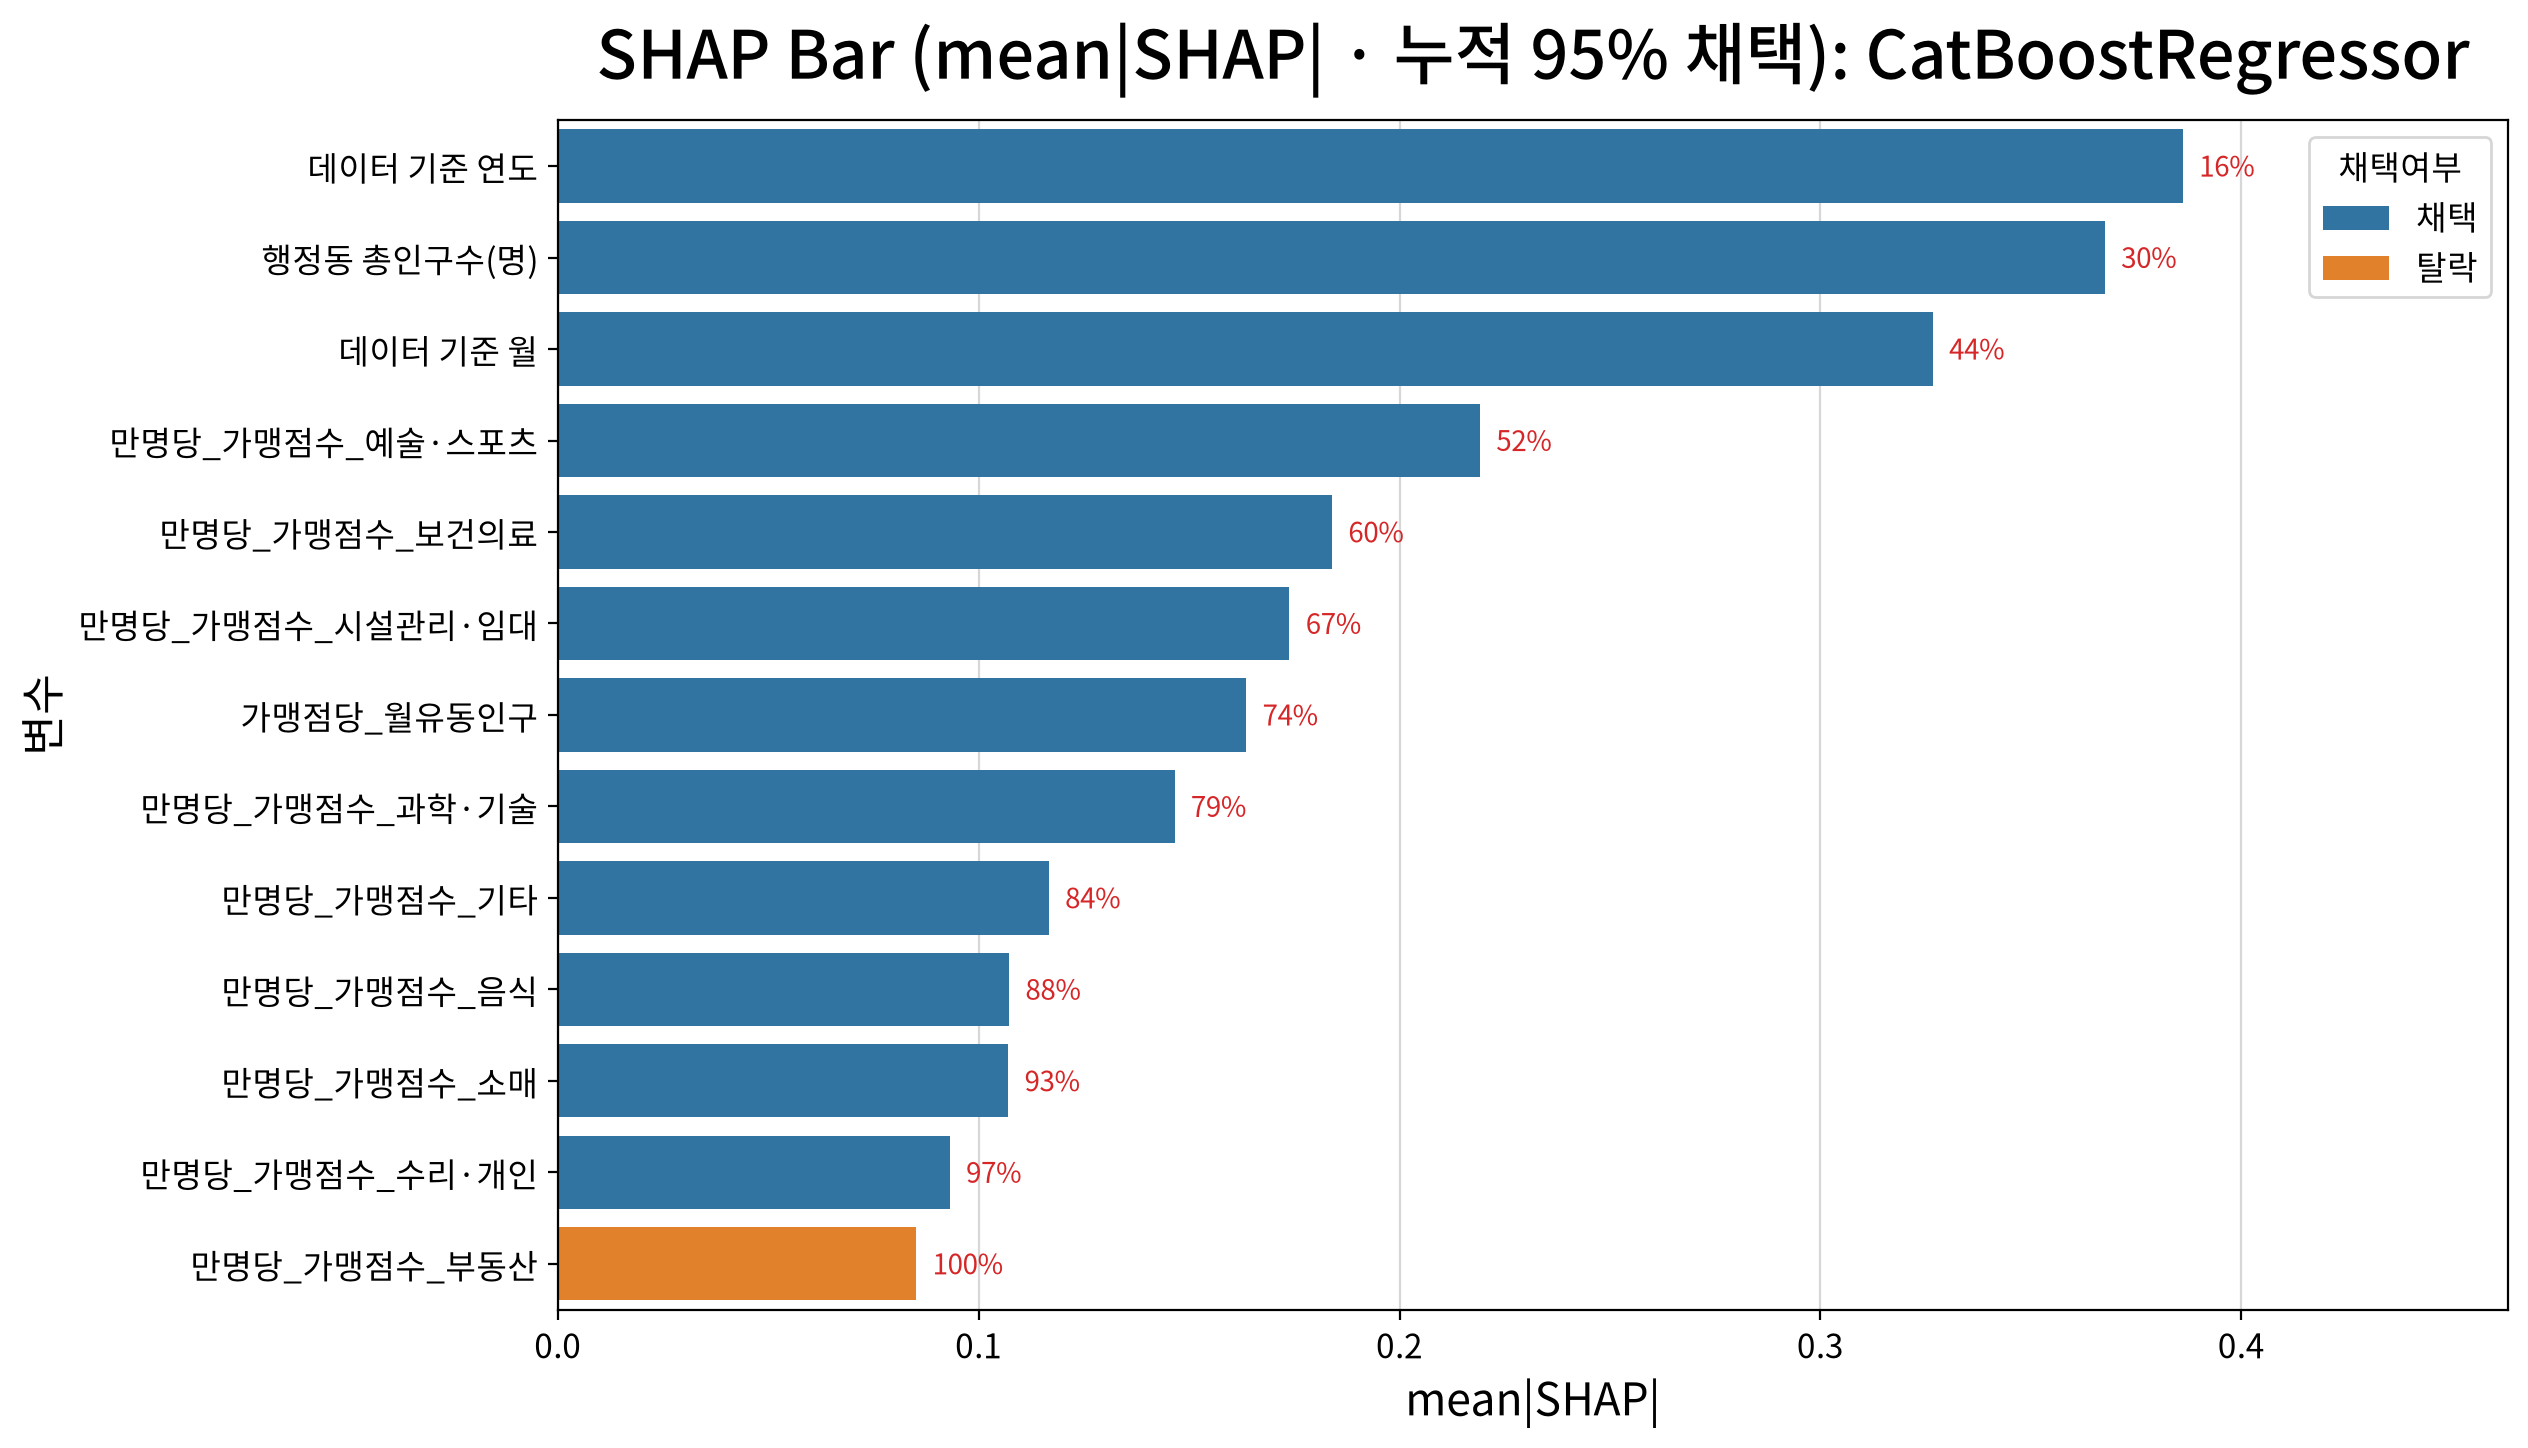

In [46]:
my_diag.shap_bar_plot(summary, cum_ratio=cum_ratio, column_means=column_means)

### 시점 정보와 인구 규모에 상대적으로 큰 예측 기여가 나타난다

- 평균 절대 SHAP 기준으로 연도·총인구수·기준월이 상위에 위치하며, 세 변수의 누적 비중은 그래프 표시상 약 44%다.
- 업종별 지표에서는 예술·스포츠와 보건의료가 상대적으로 높은 순위에 있다. 이는 해당 지표가 분석된 예측값을 기준값에서 이동시키는 평균적인 크기가 컸다는 의미다.
- 부동산 지표는 평균 절대 기여가 가장 작지만 0은 아니다. 그래프의 누적 95% 표시에서 제외됐다는 사실을 모델에서 제거됐다는 뜻으로 해석하지 않는다.
- 앞선 변수 중요도와 SHAP은 평가 방식이 다르고 동일 모델 여부도 확인되지 않아, 순위 차이를 변수의 역할 변화로 단정하지 않는다.

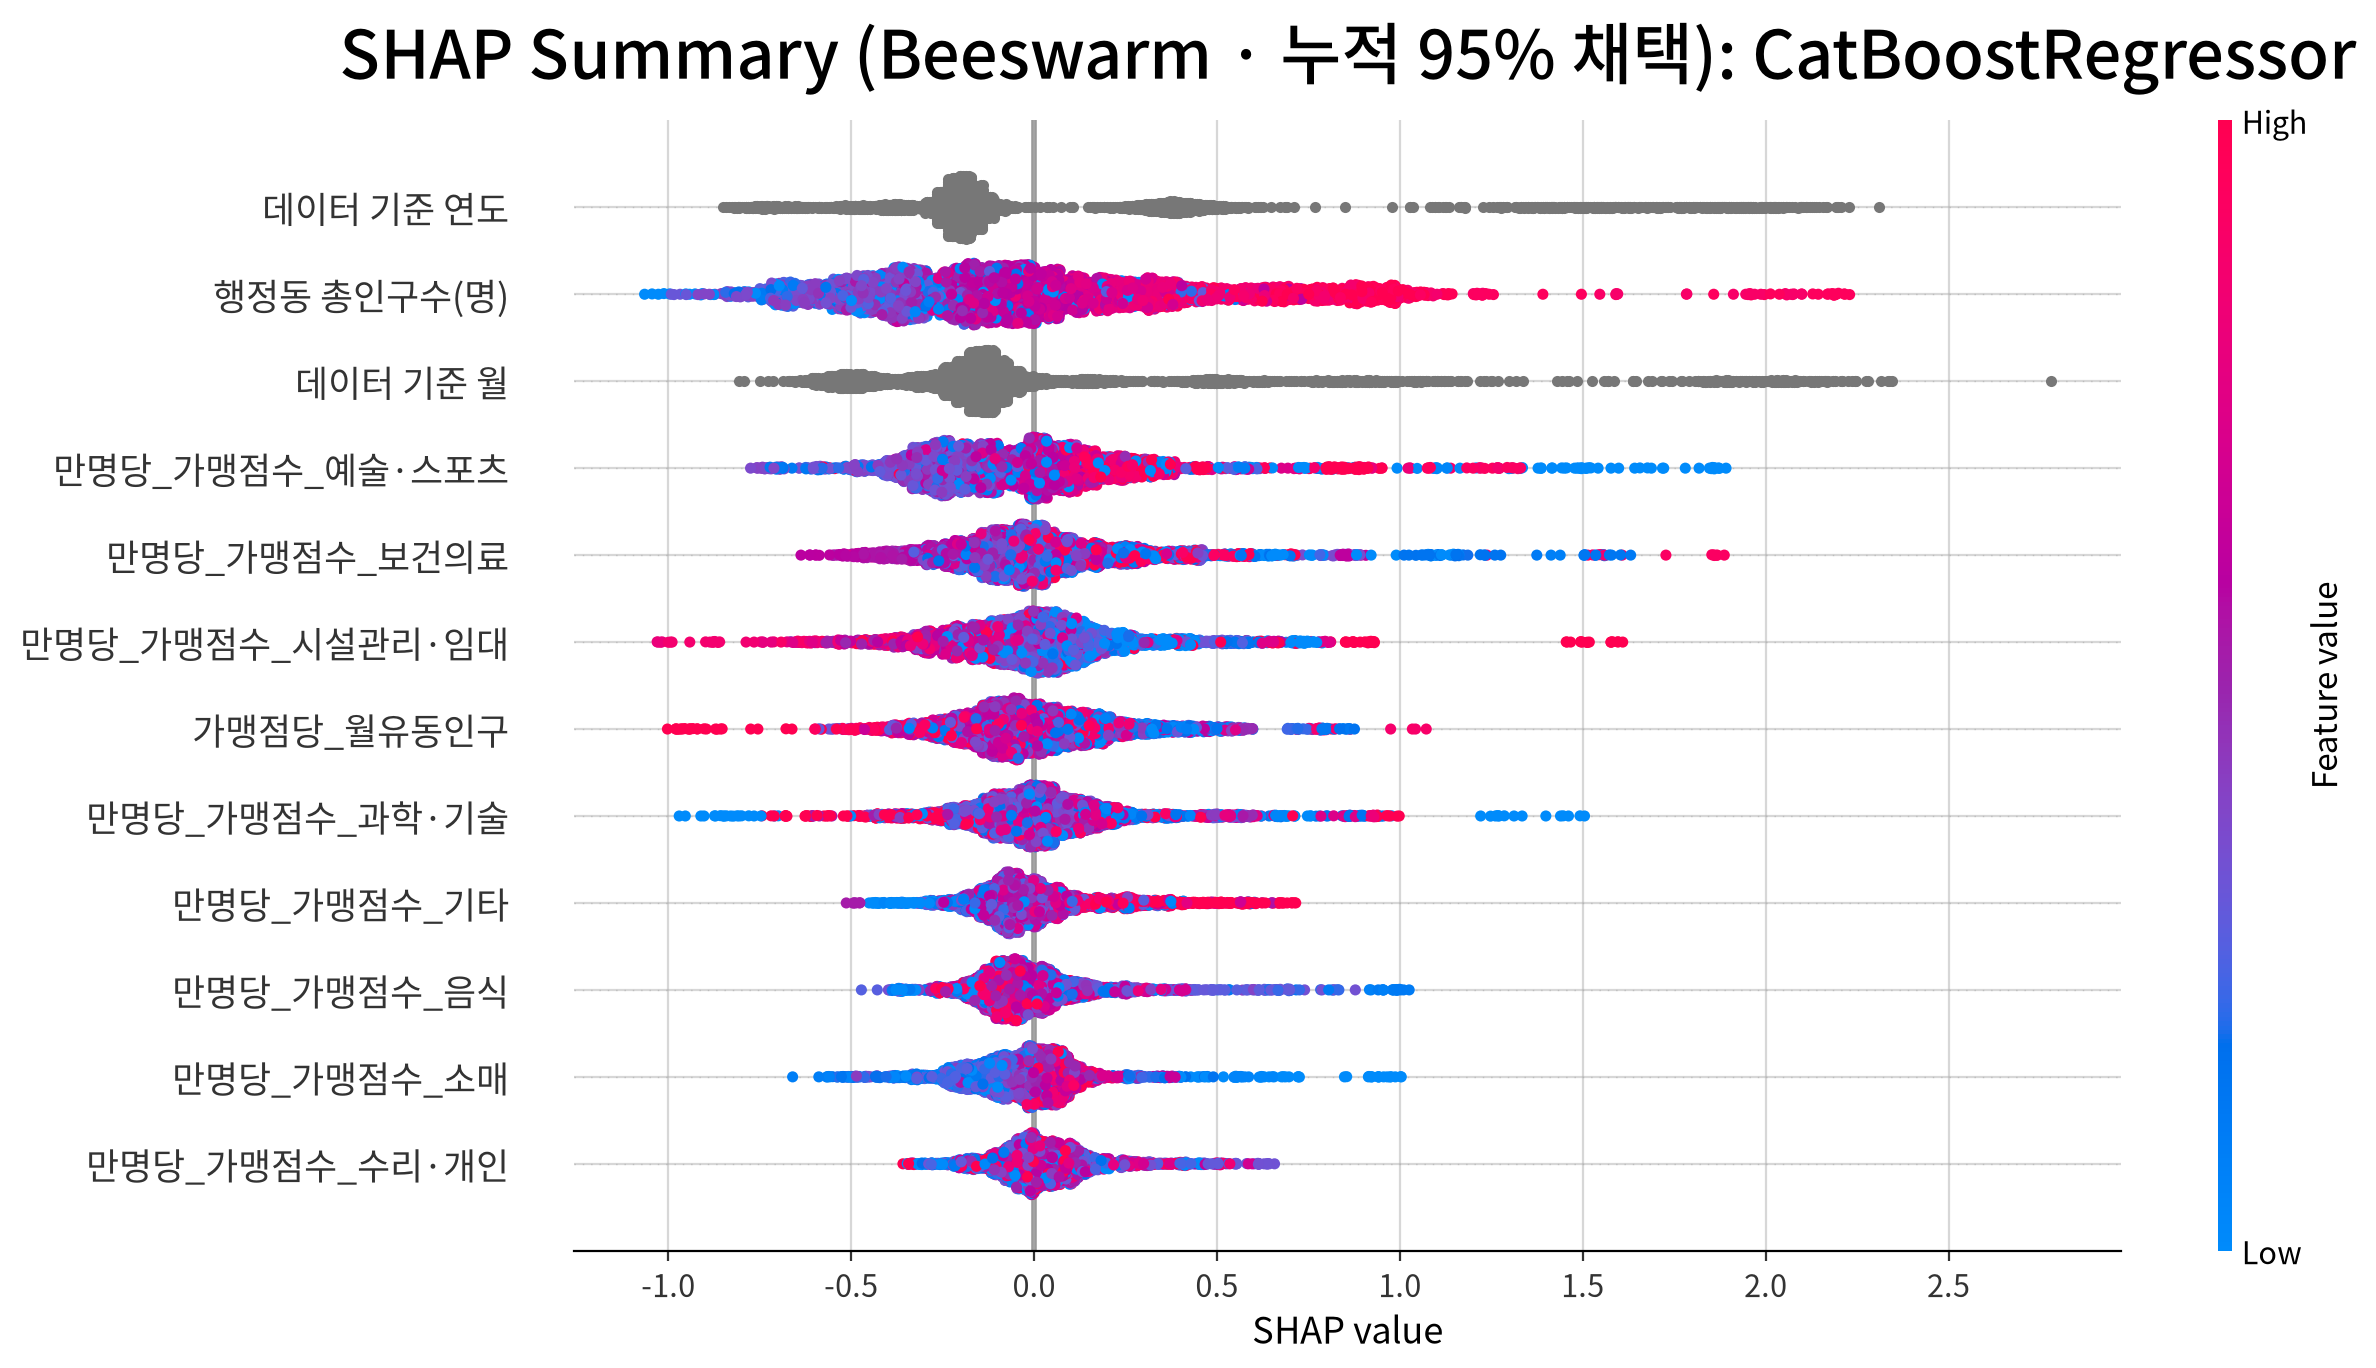

In [47]:
my_diag.shap_summary_plot(summary,
                          cum_ratio=cum_ratio,
                          column_means=column_means)

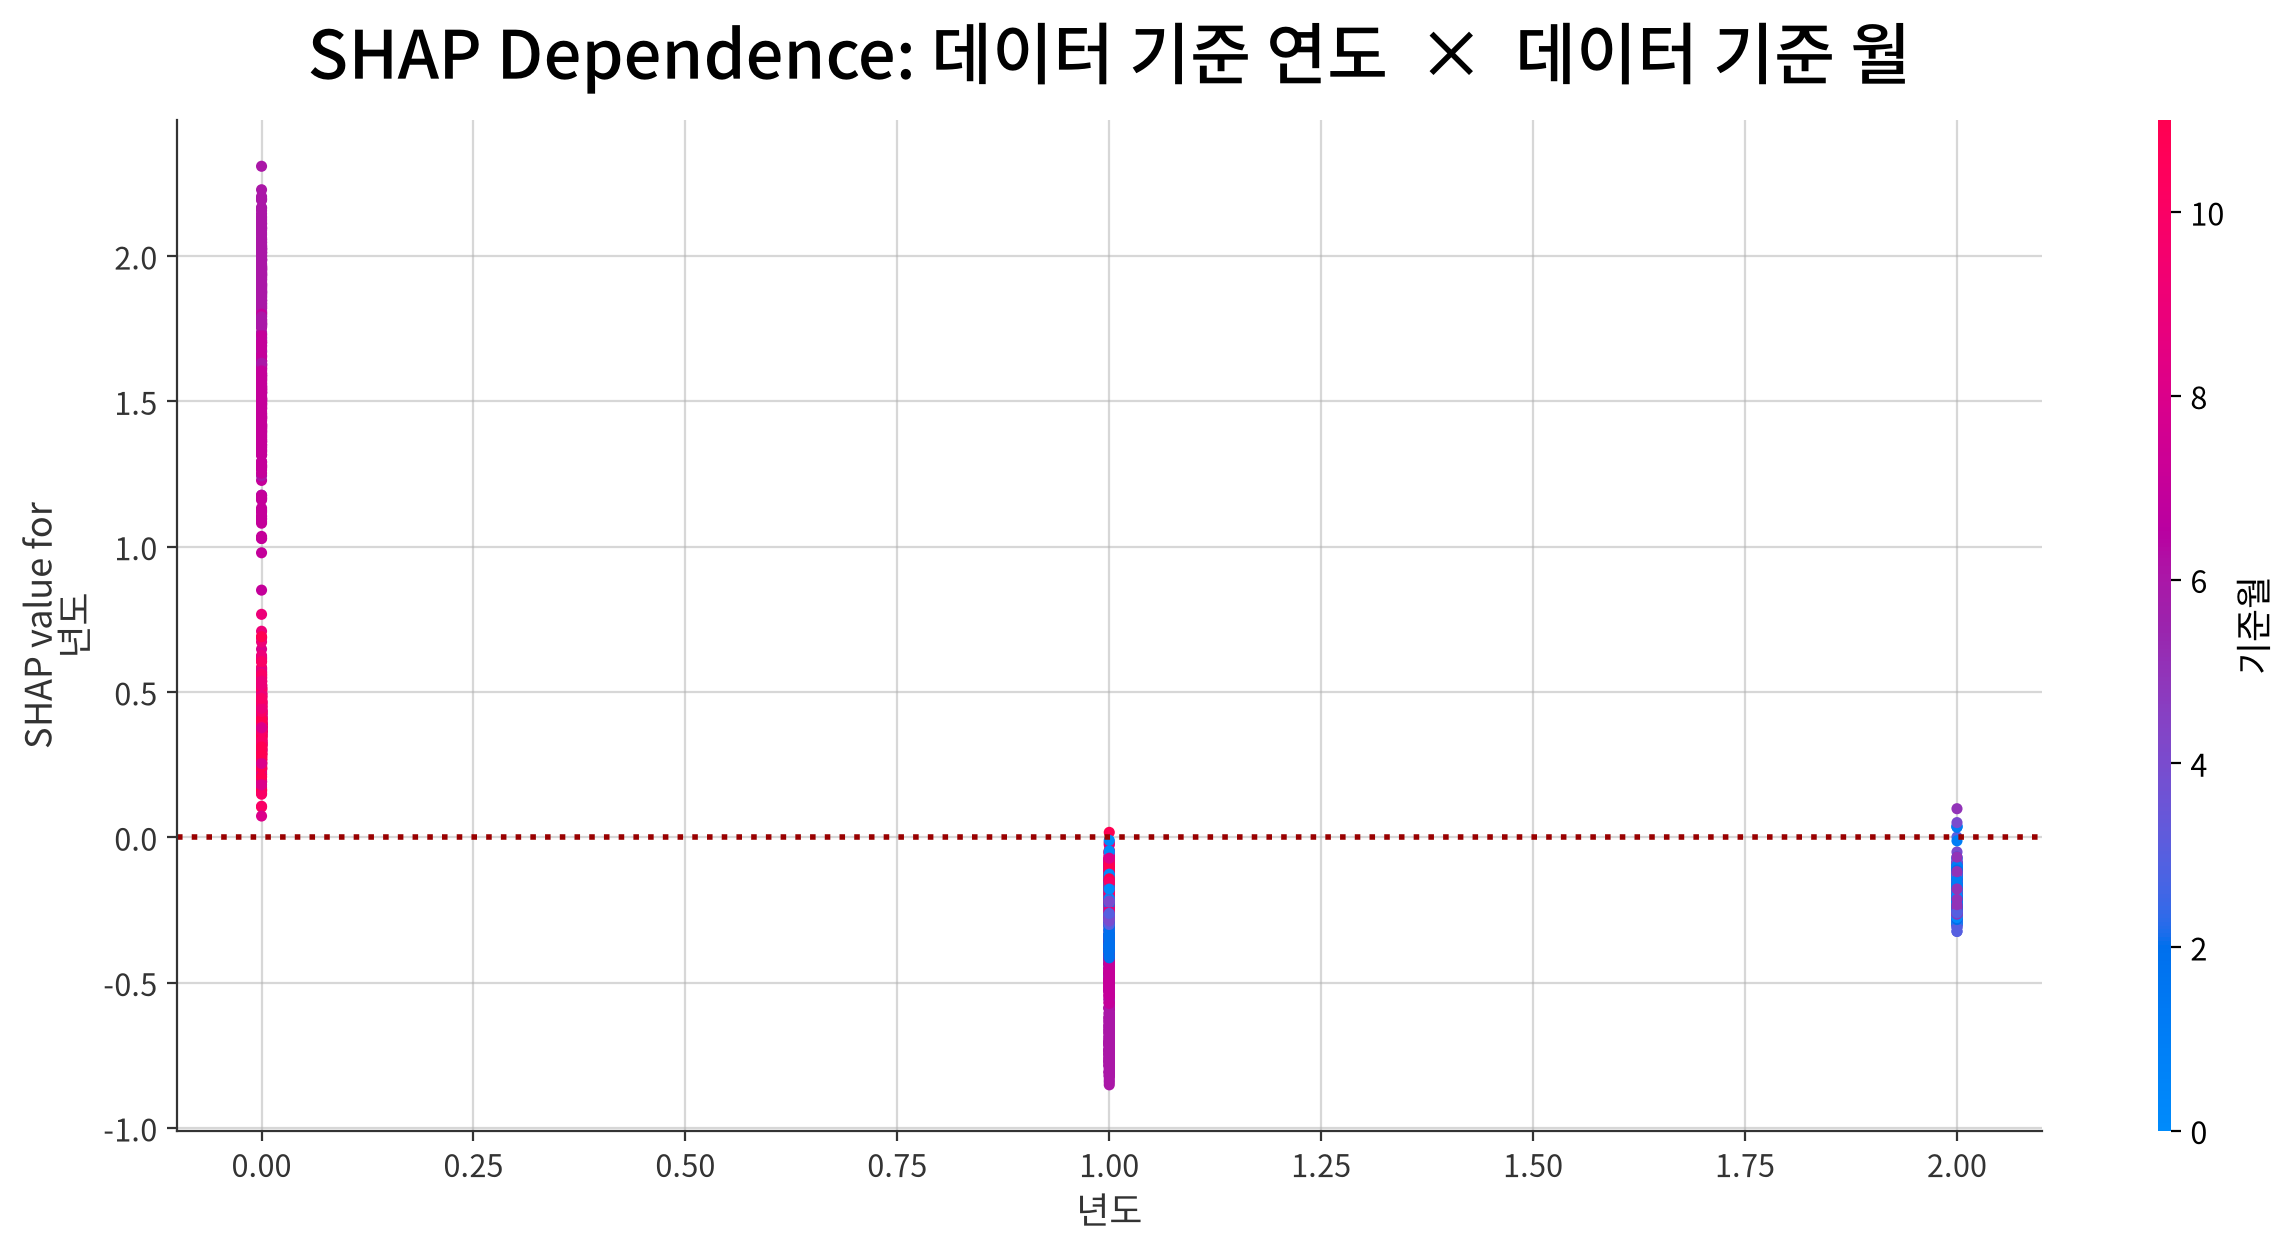

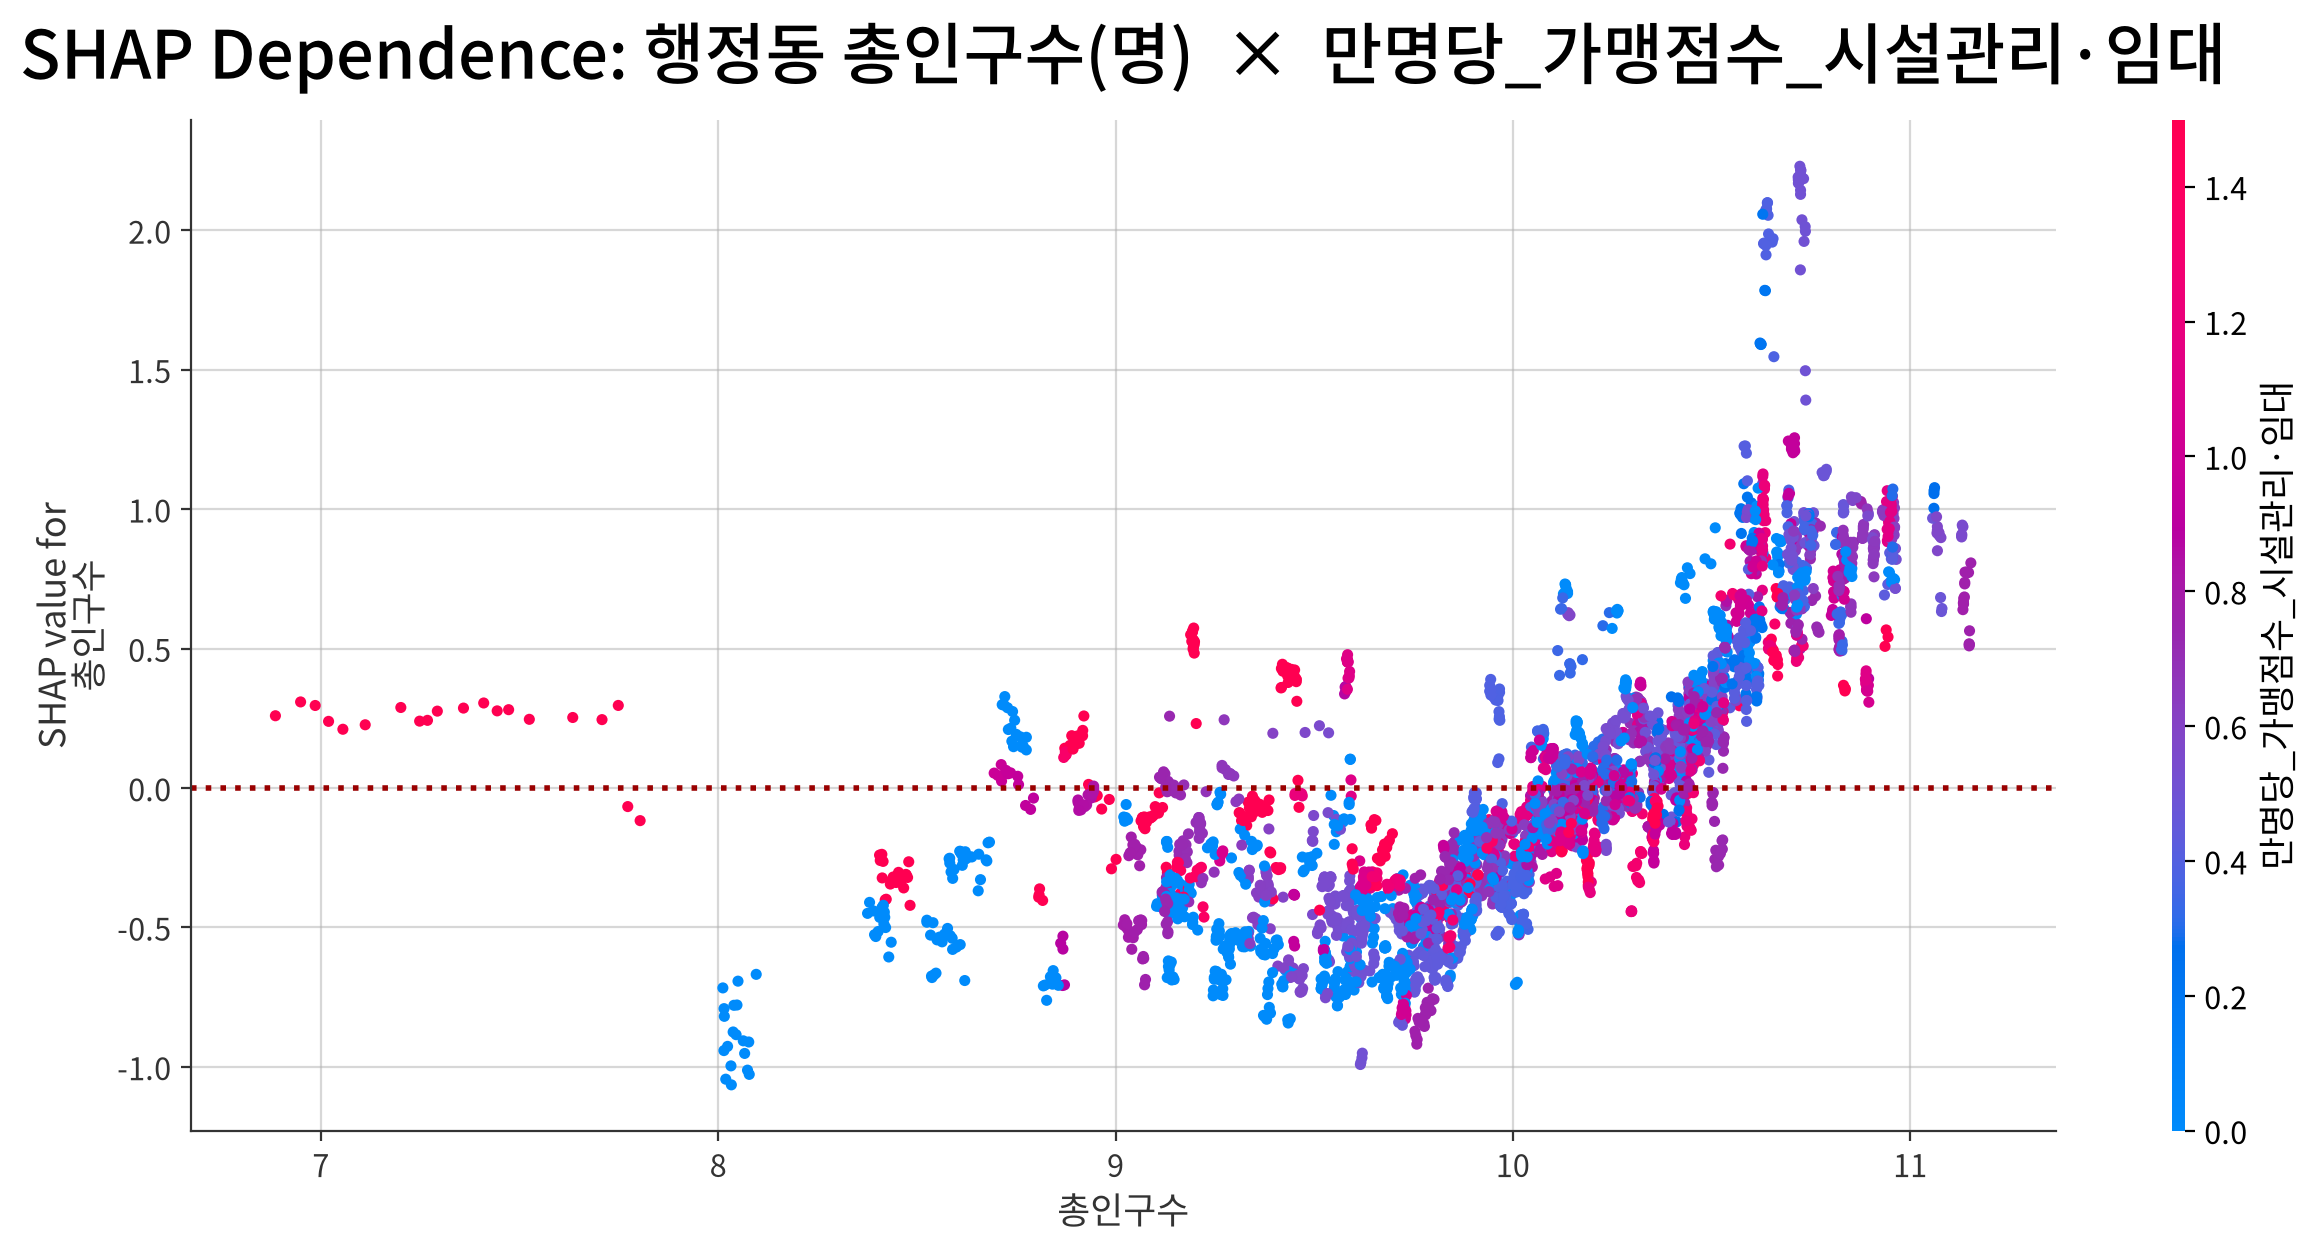

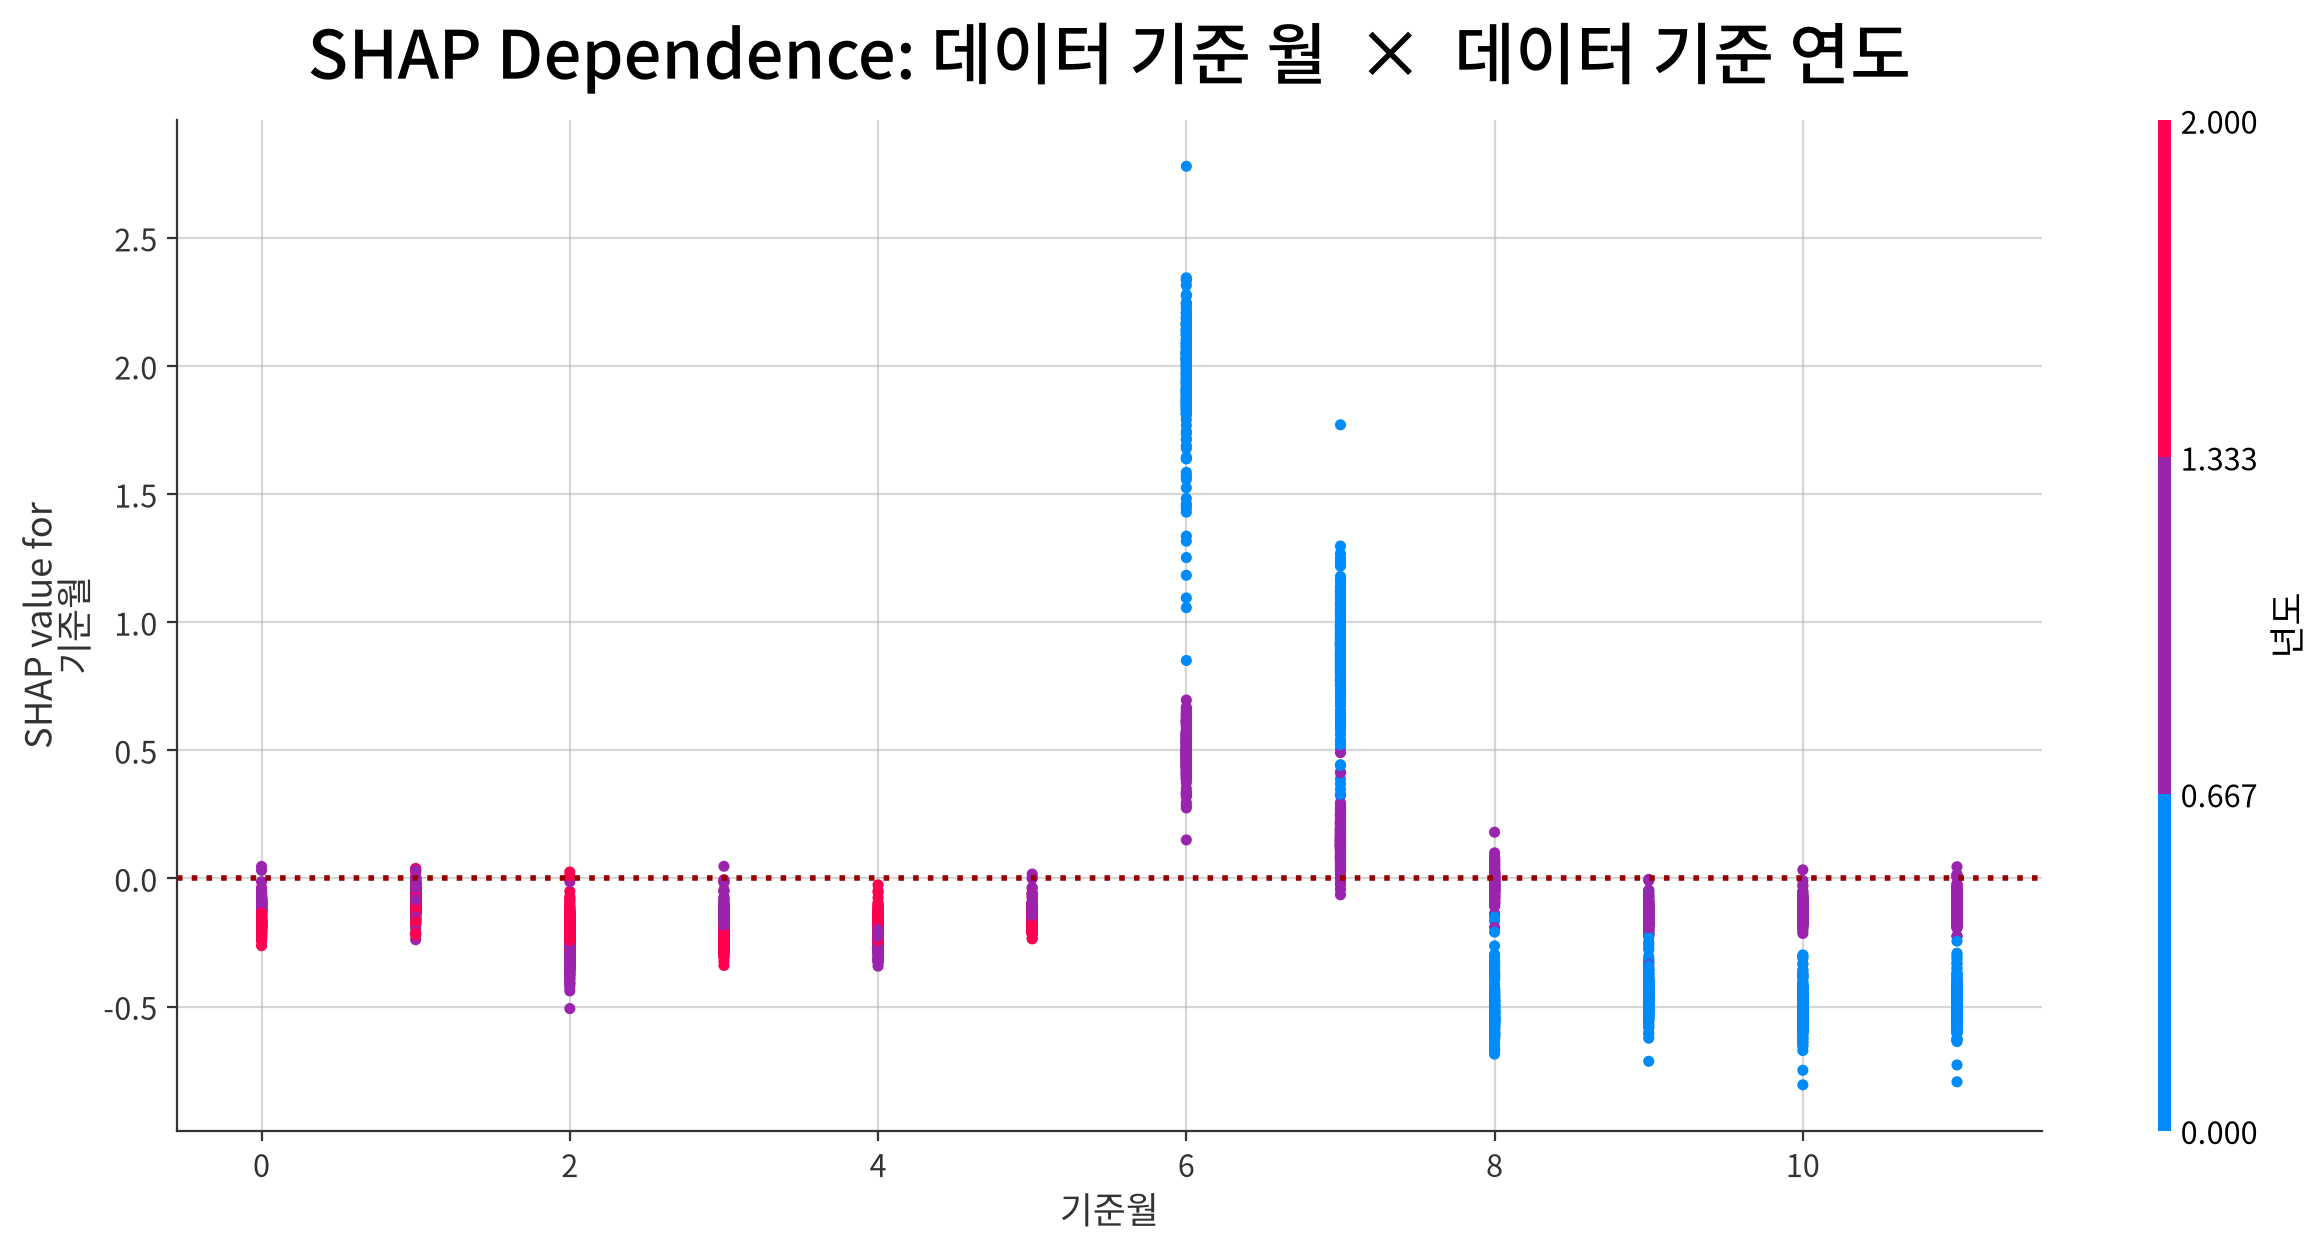

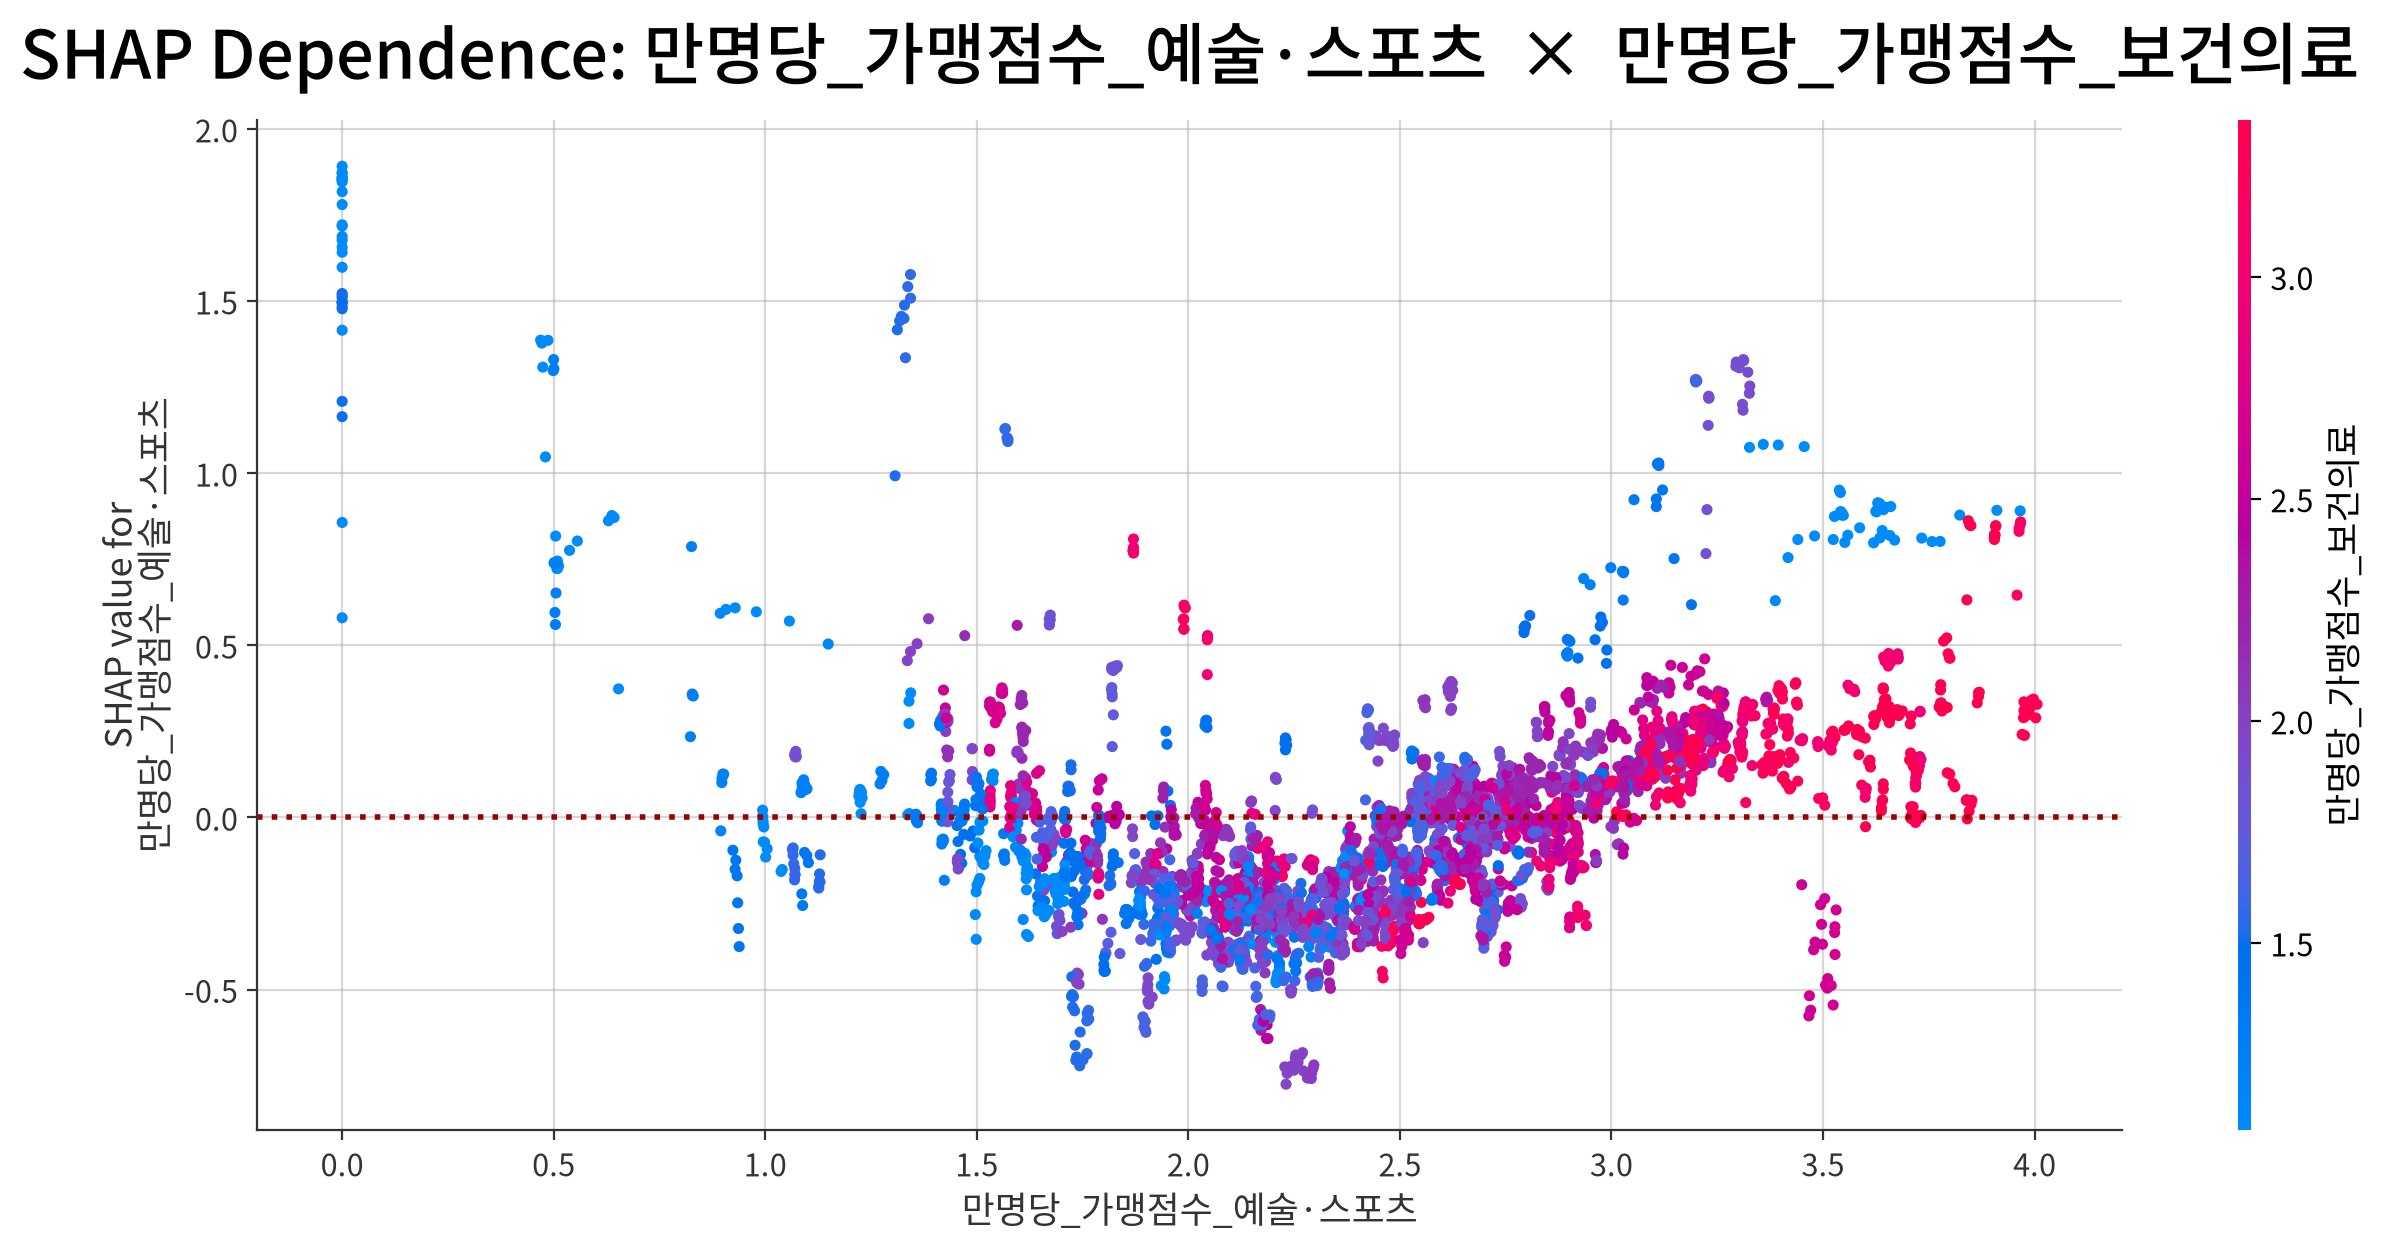

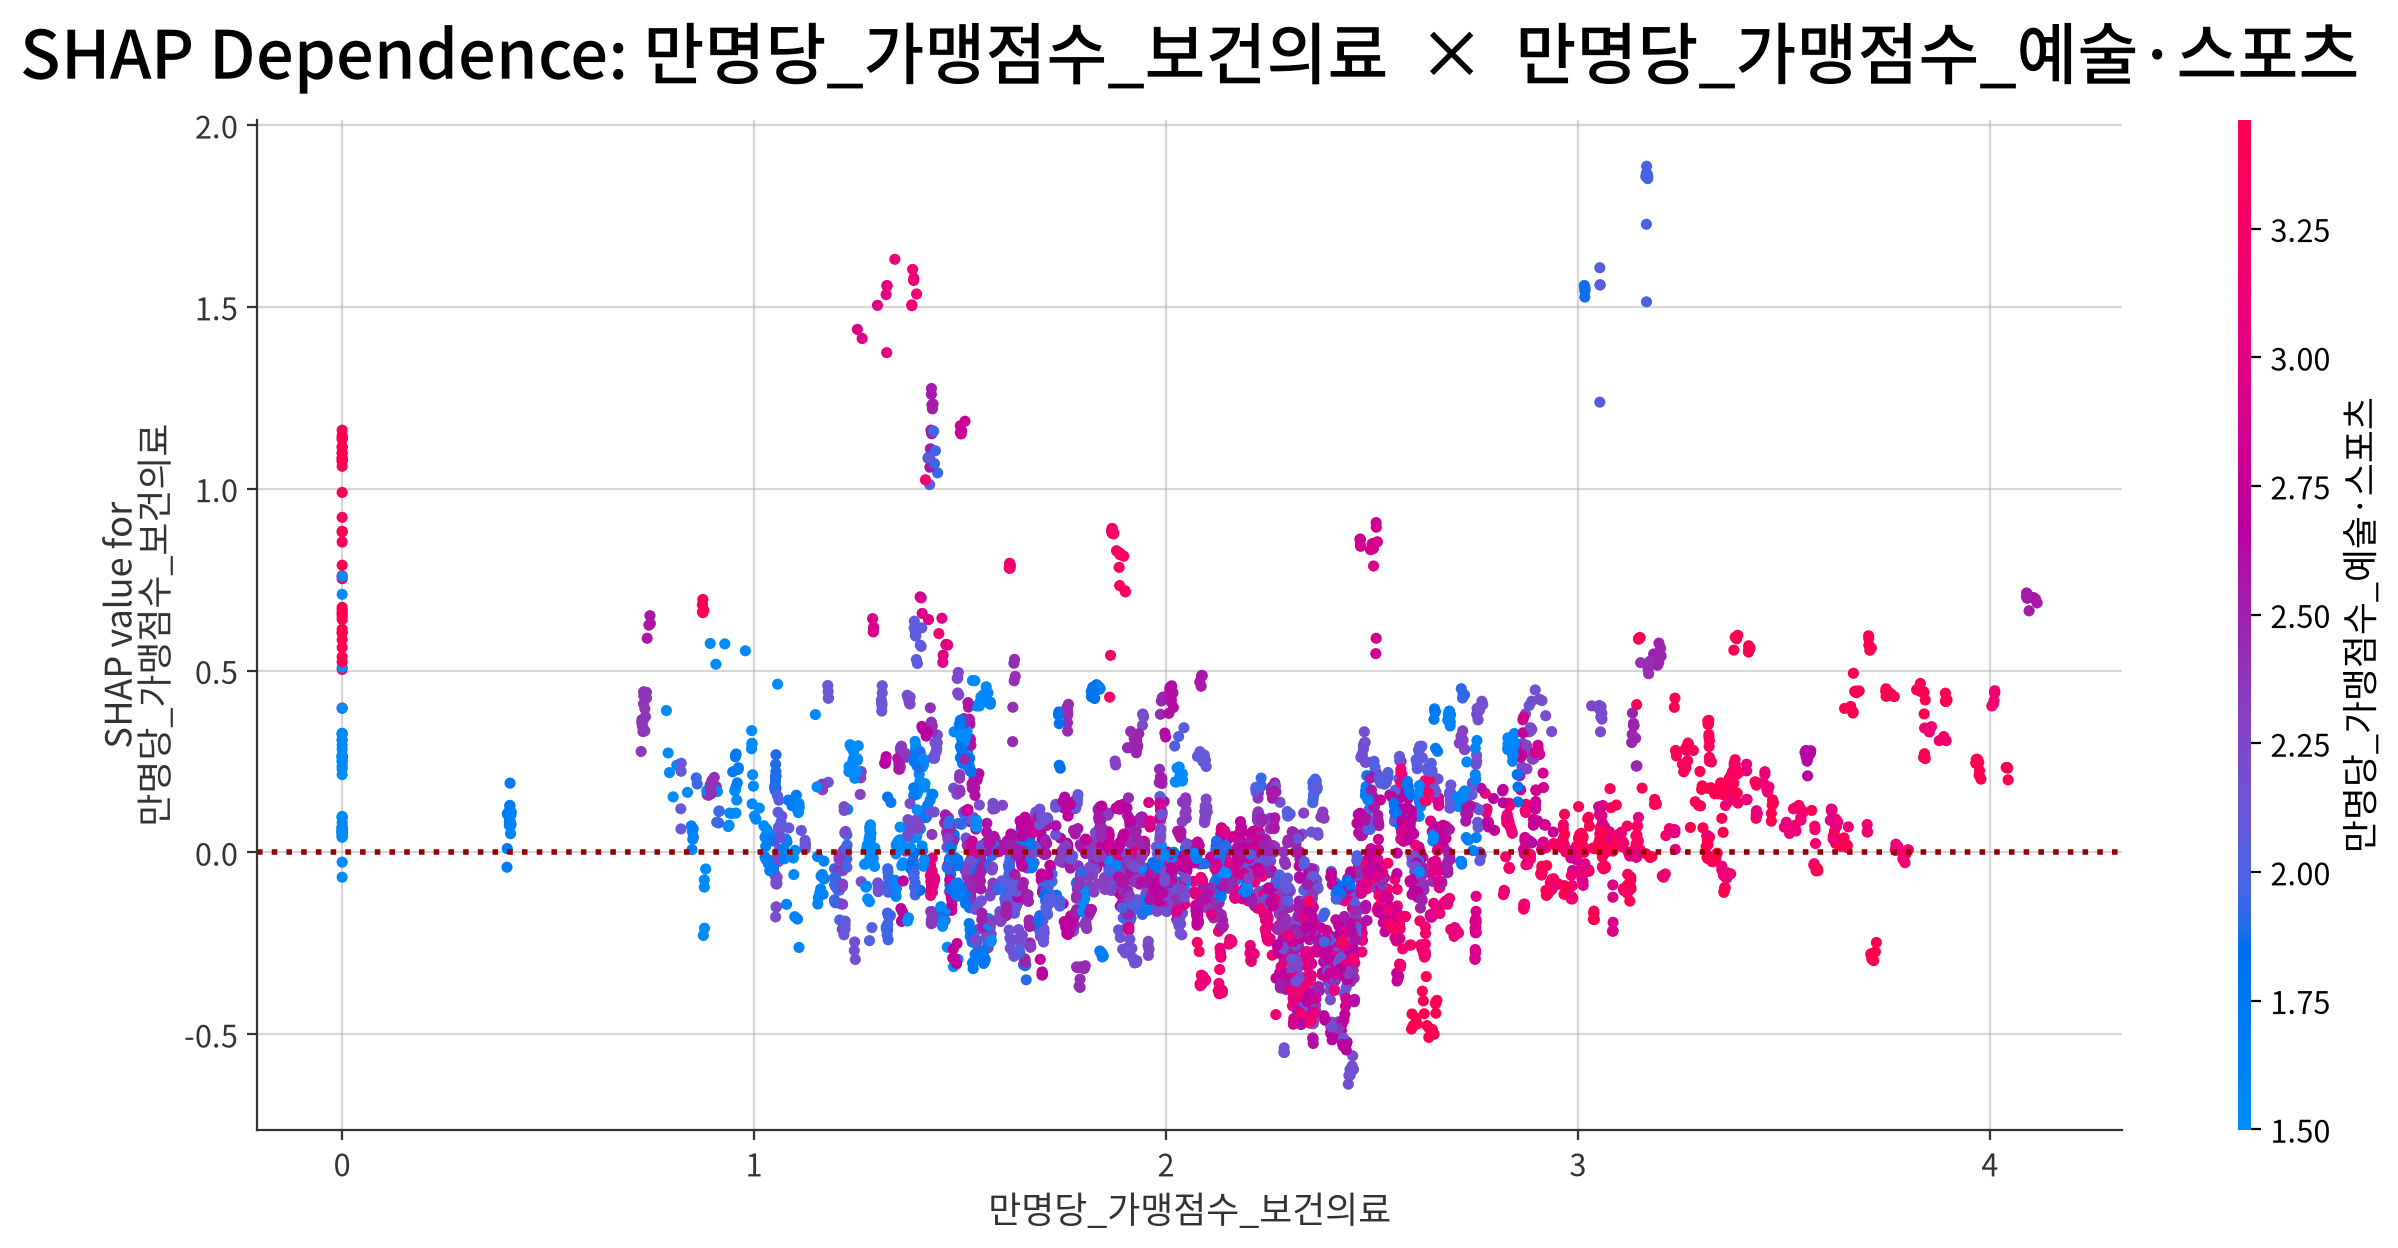

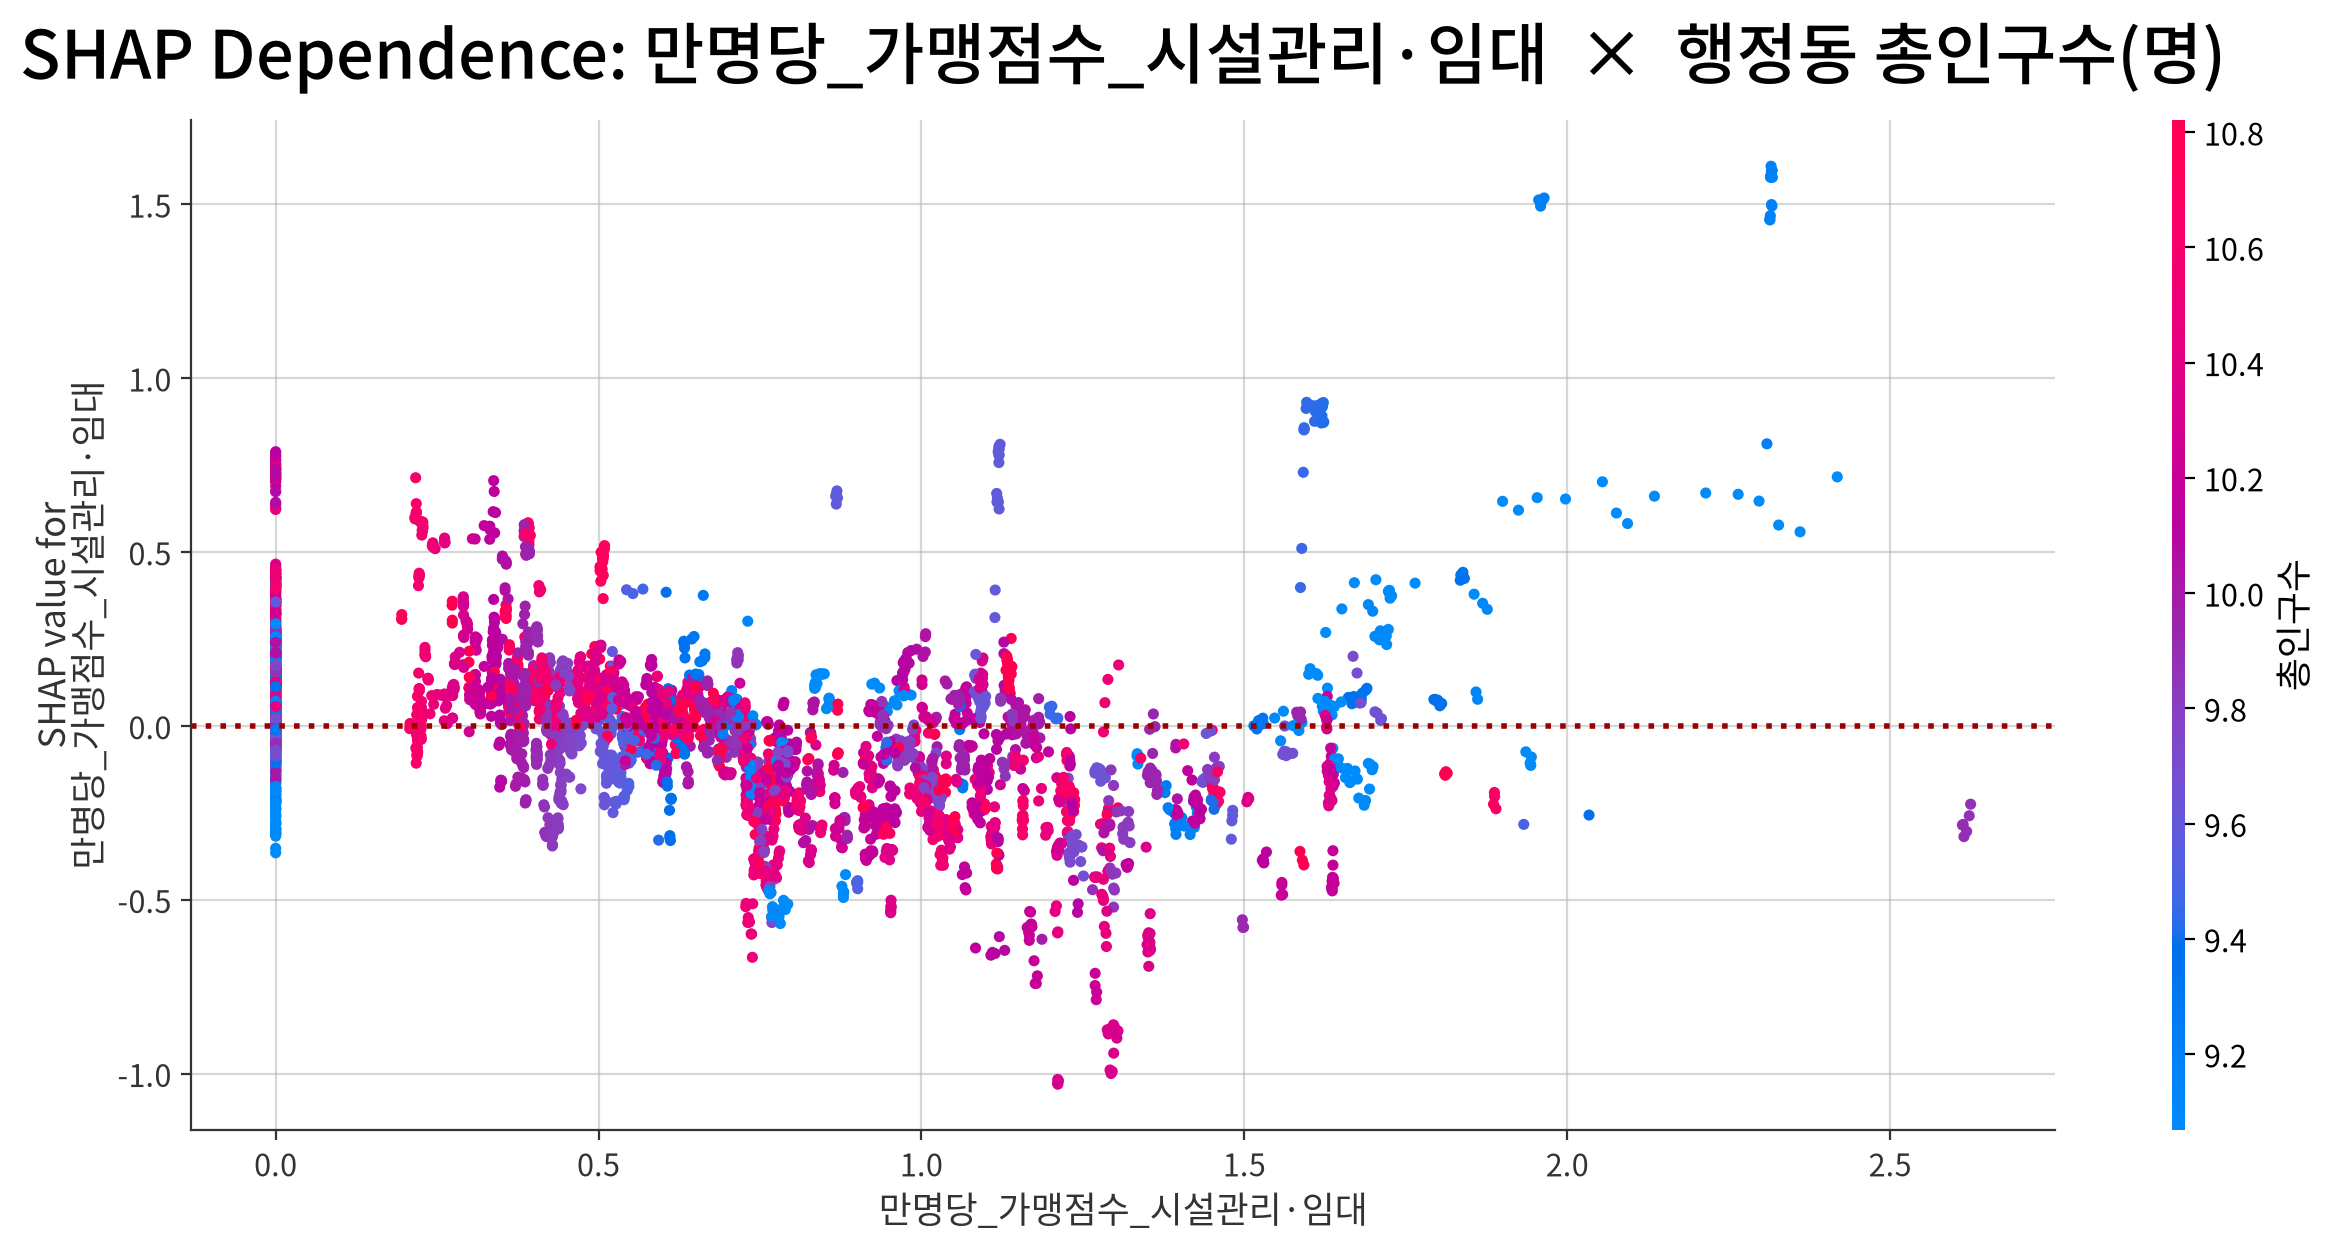

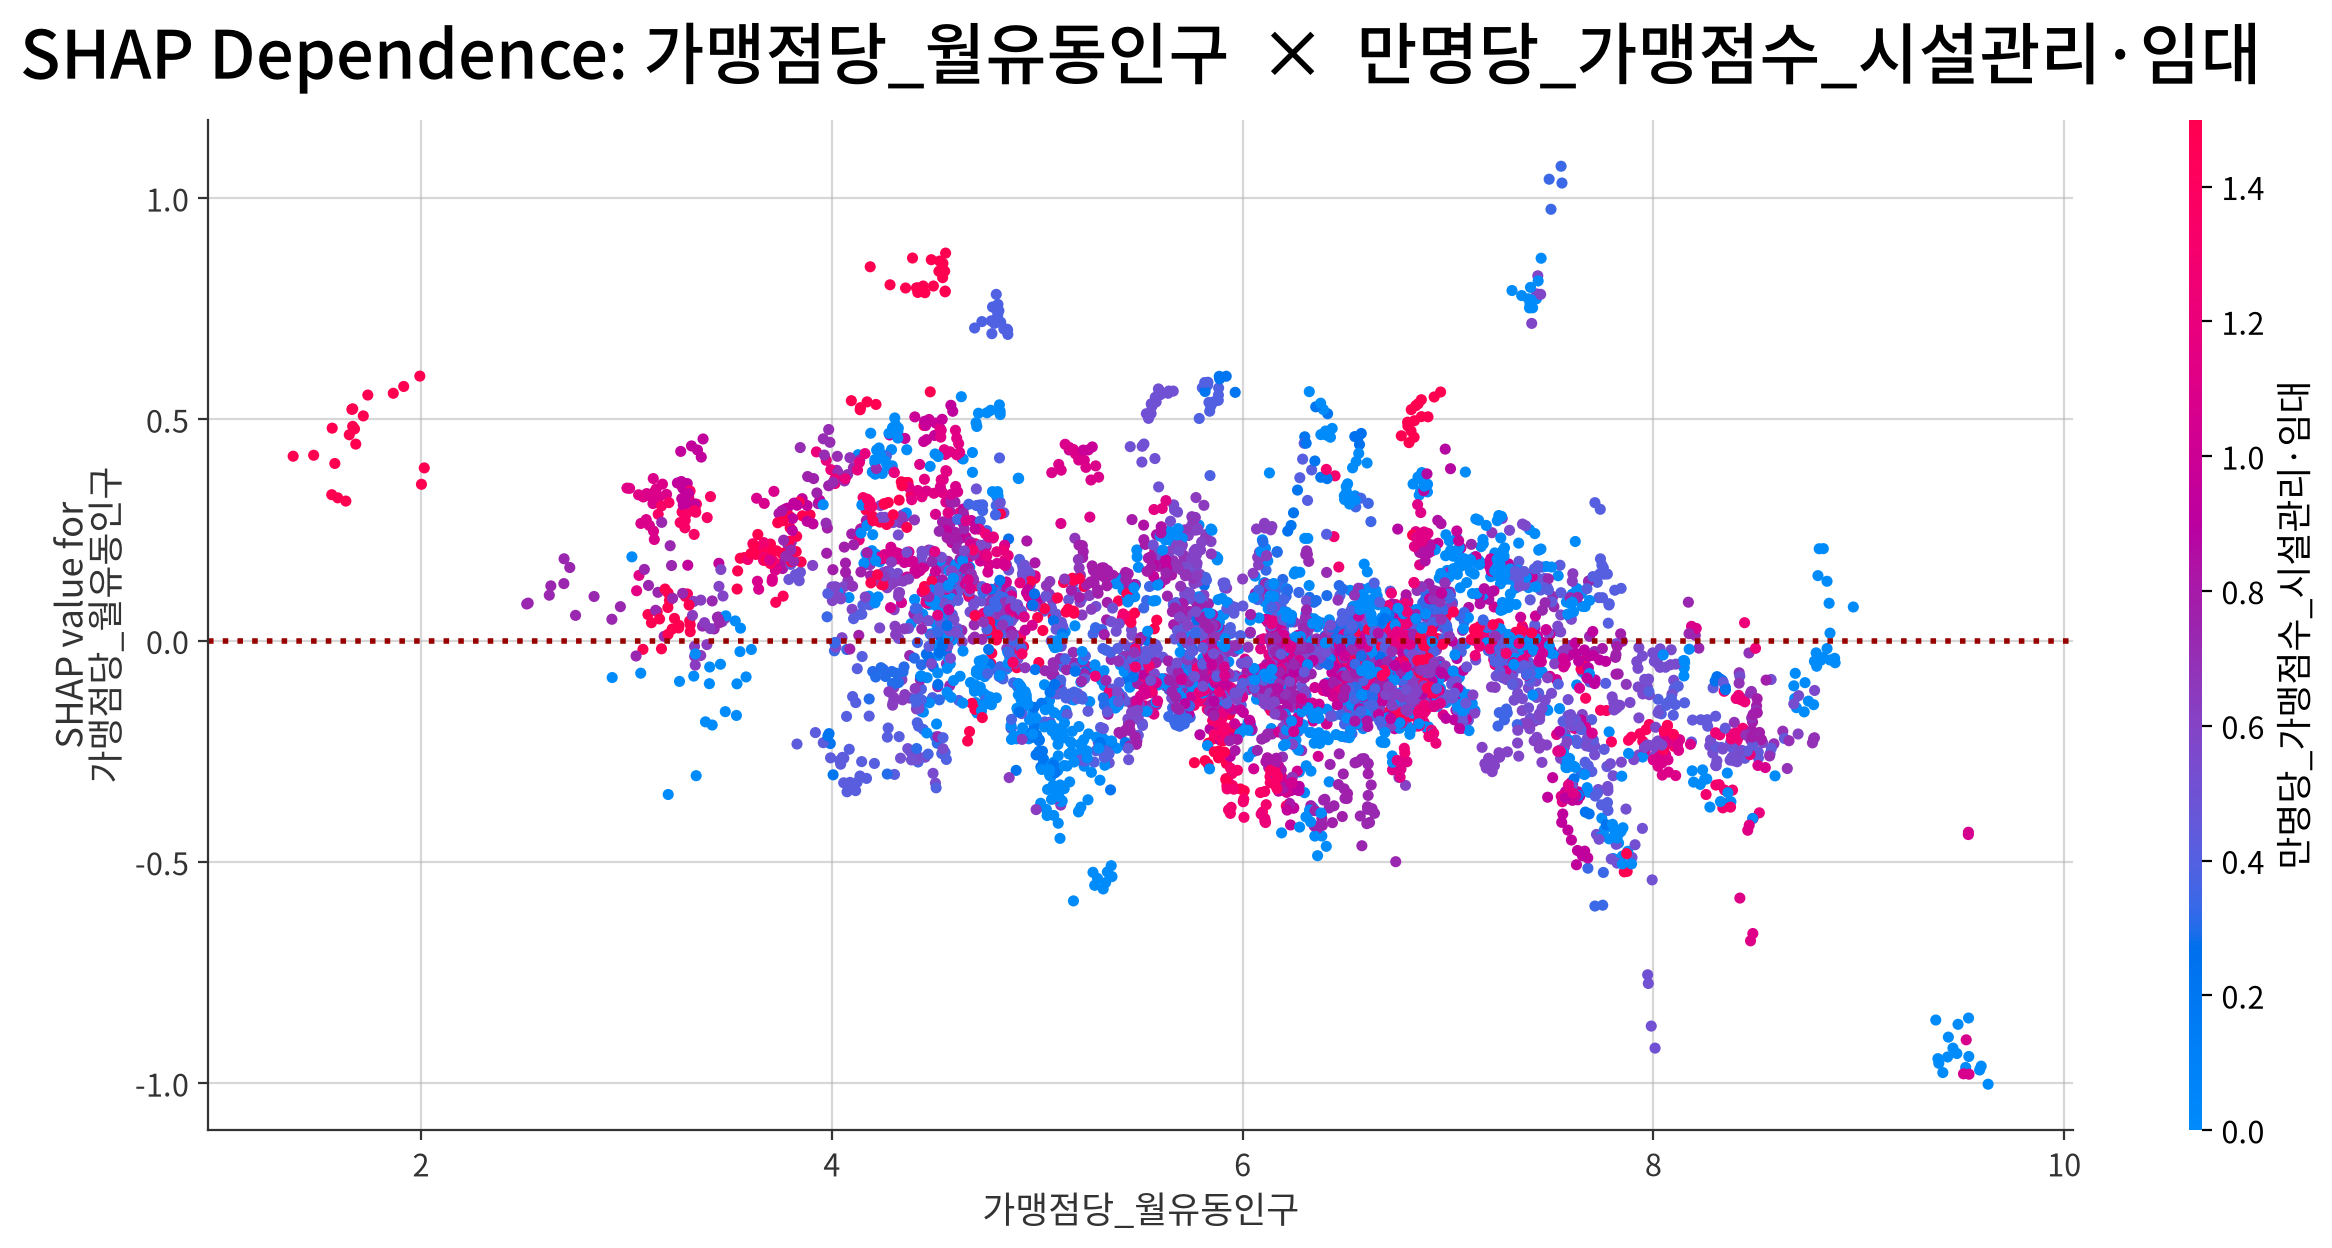

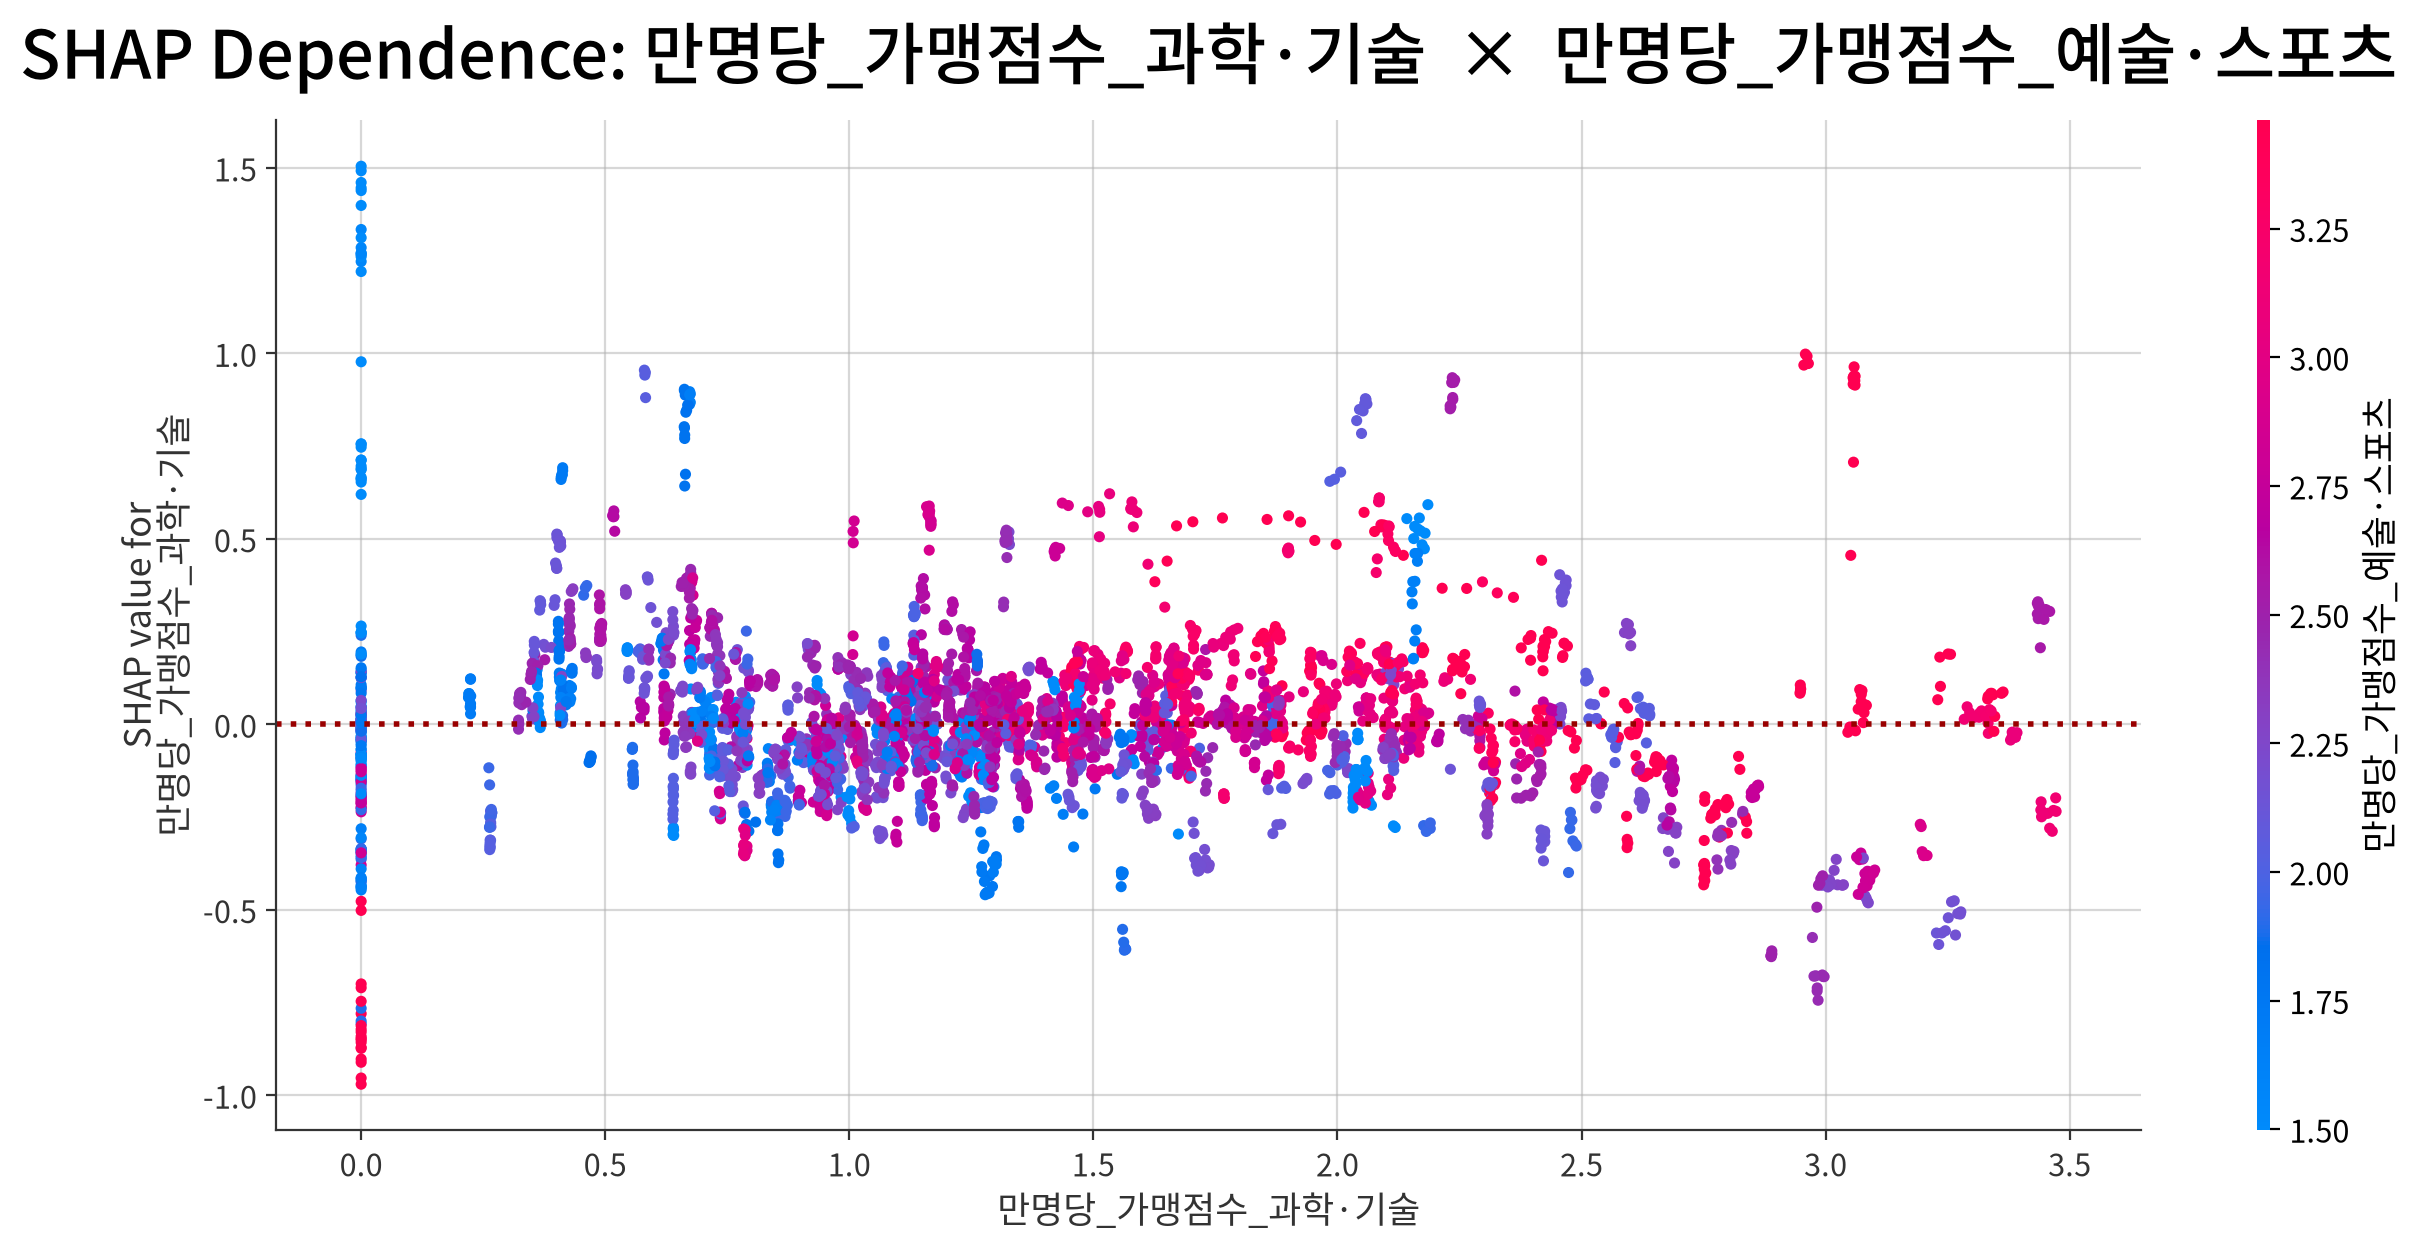

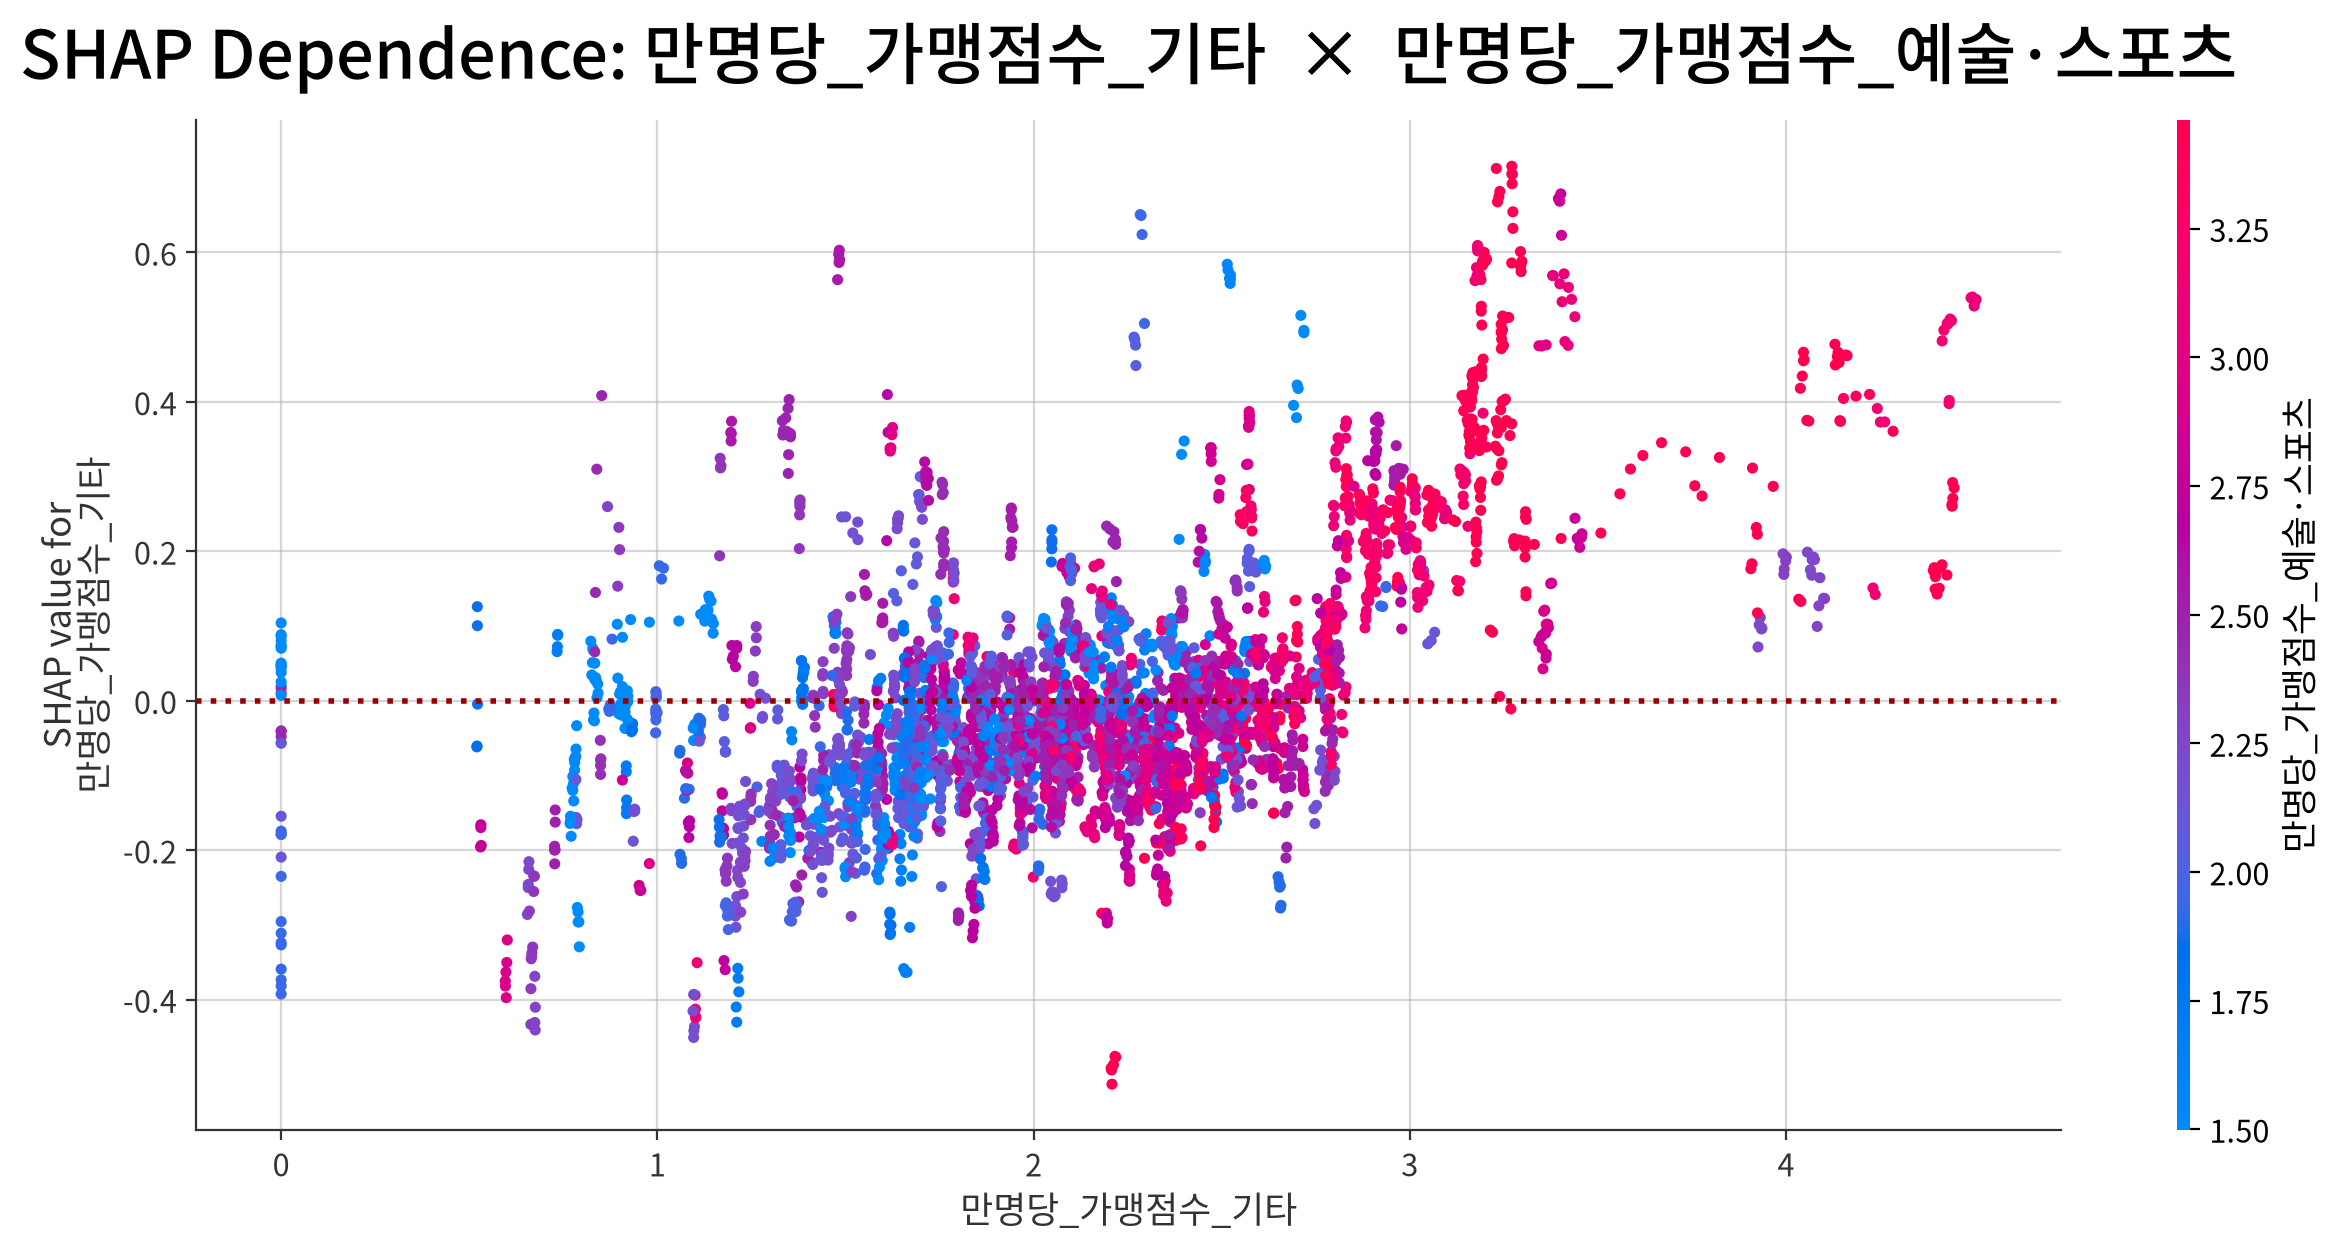

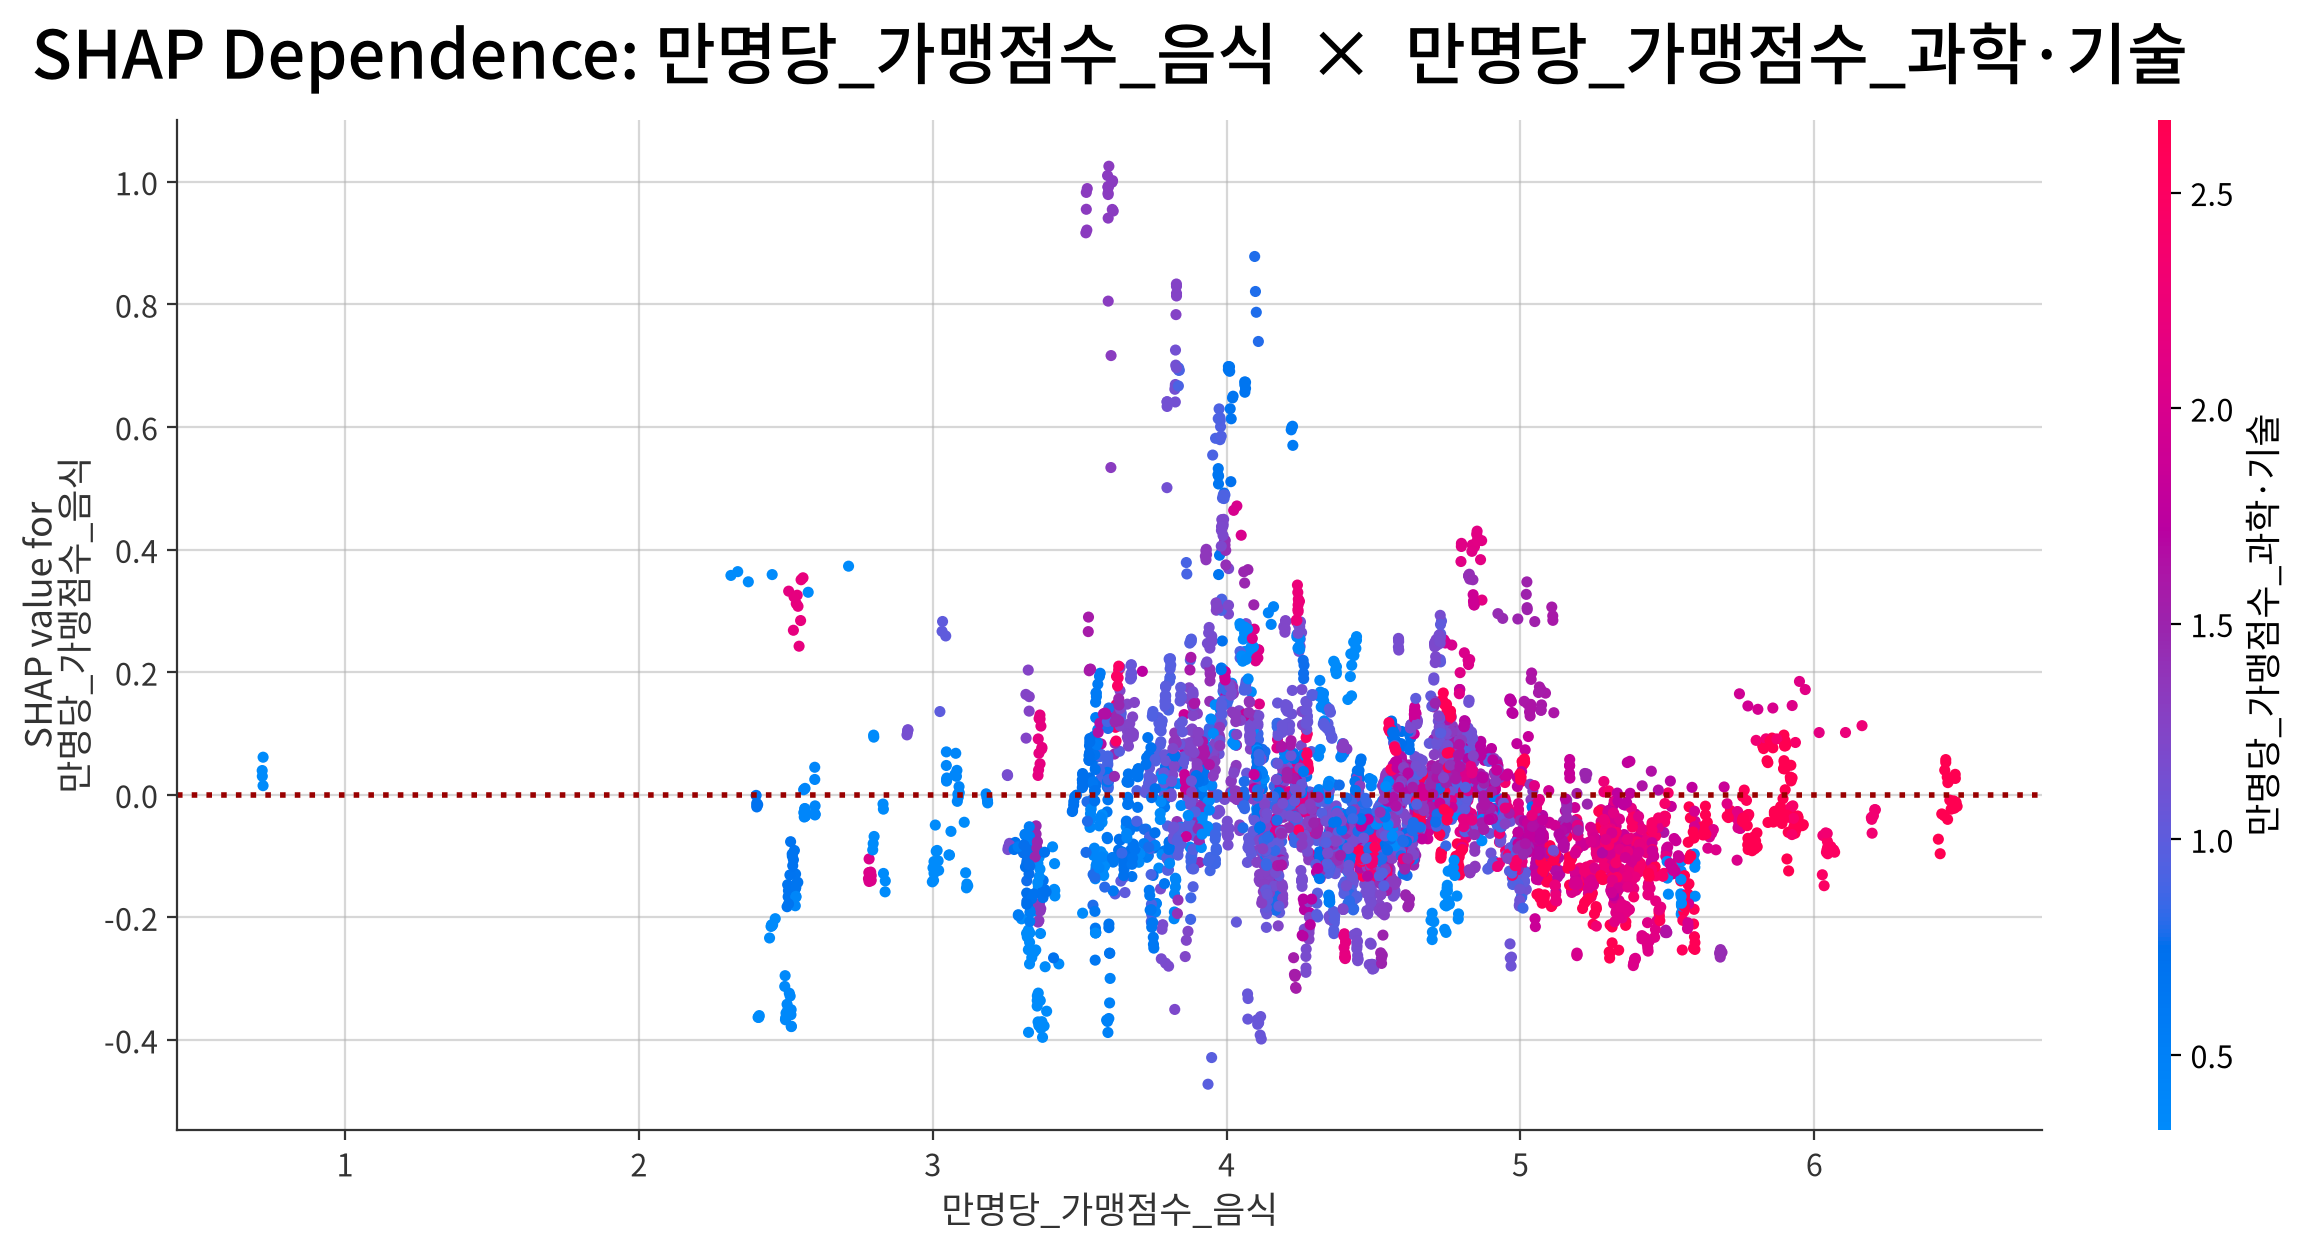

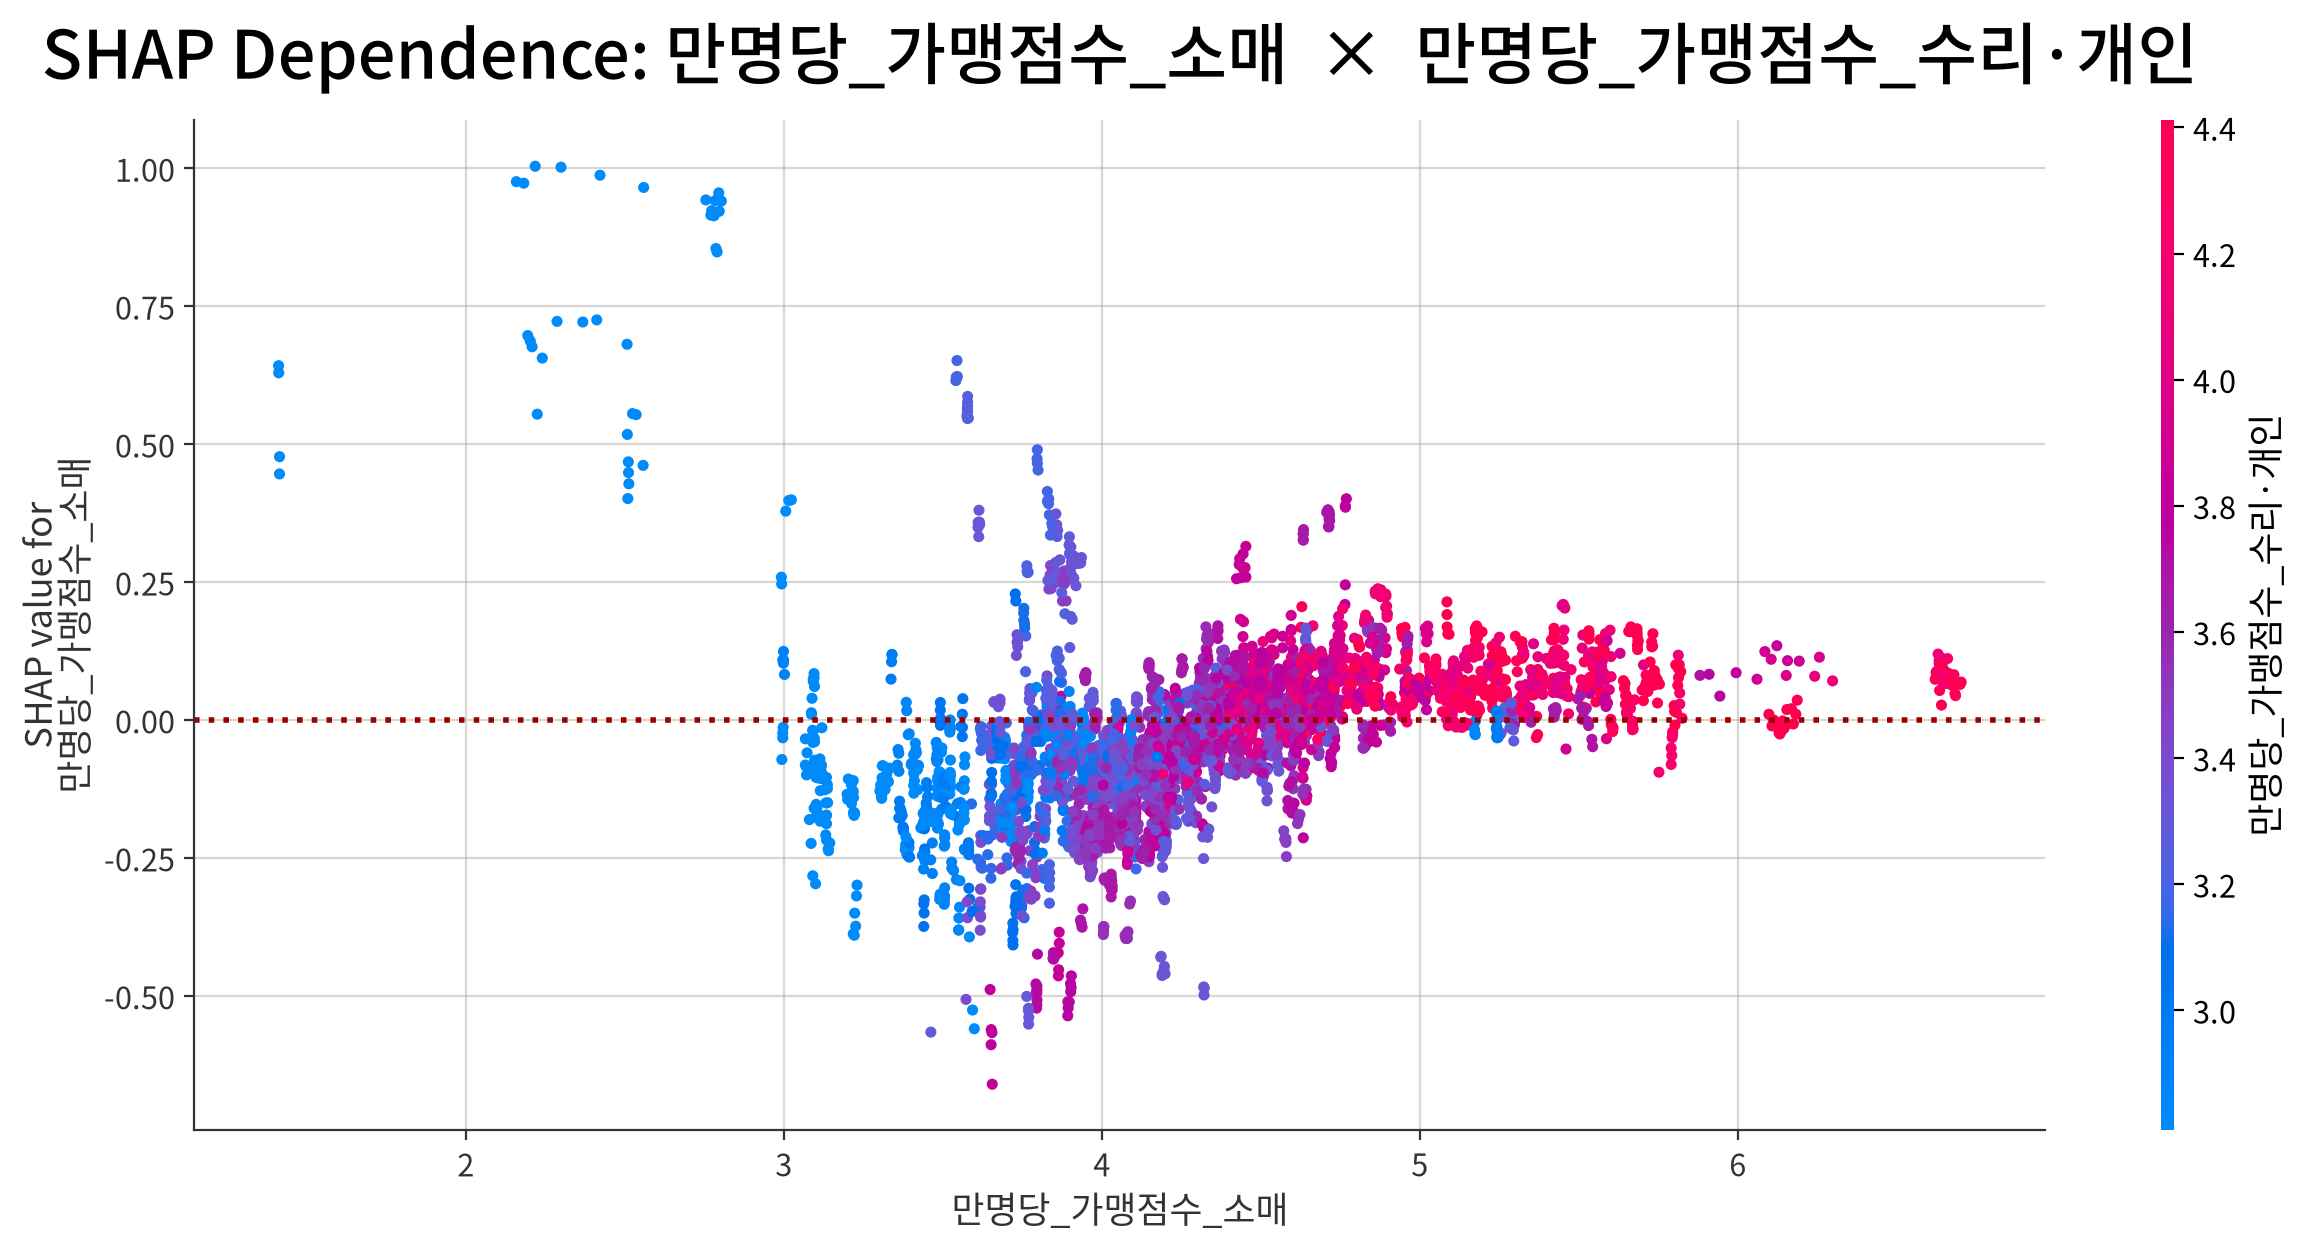

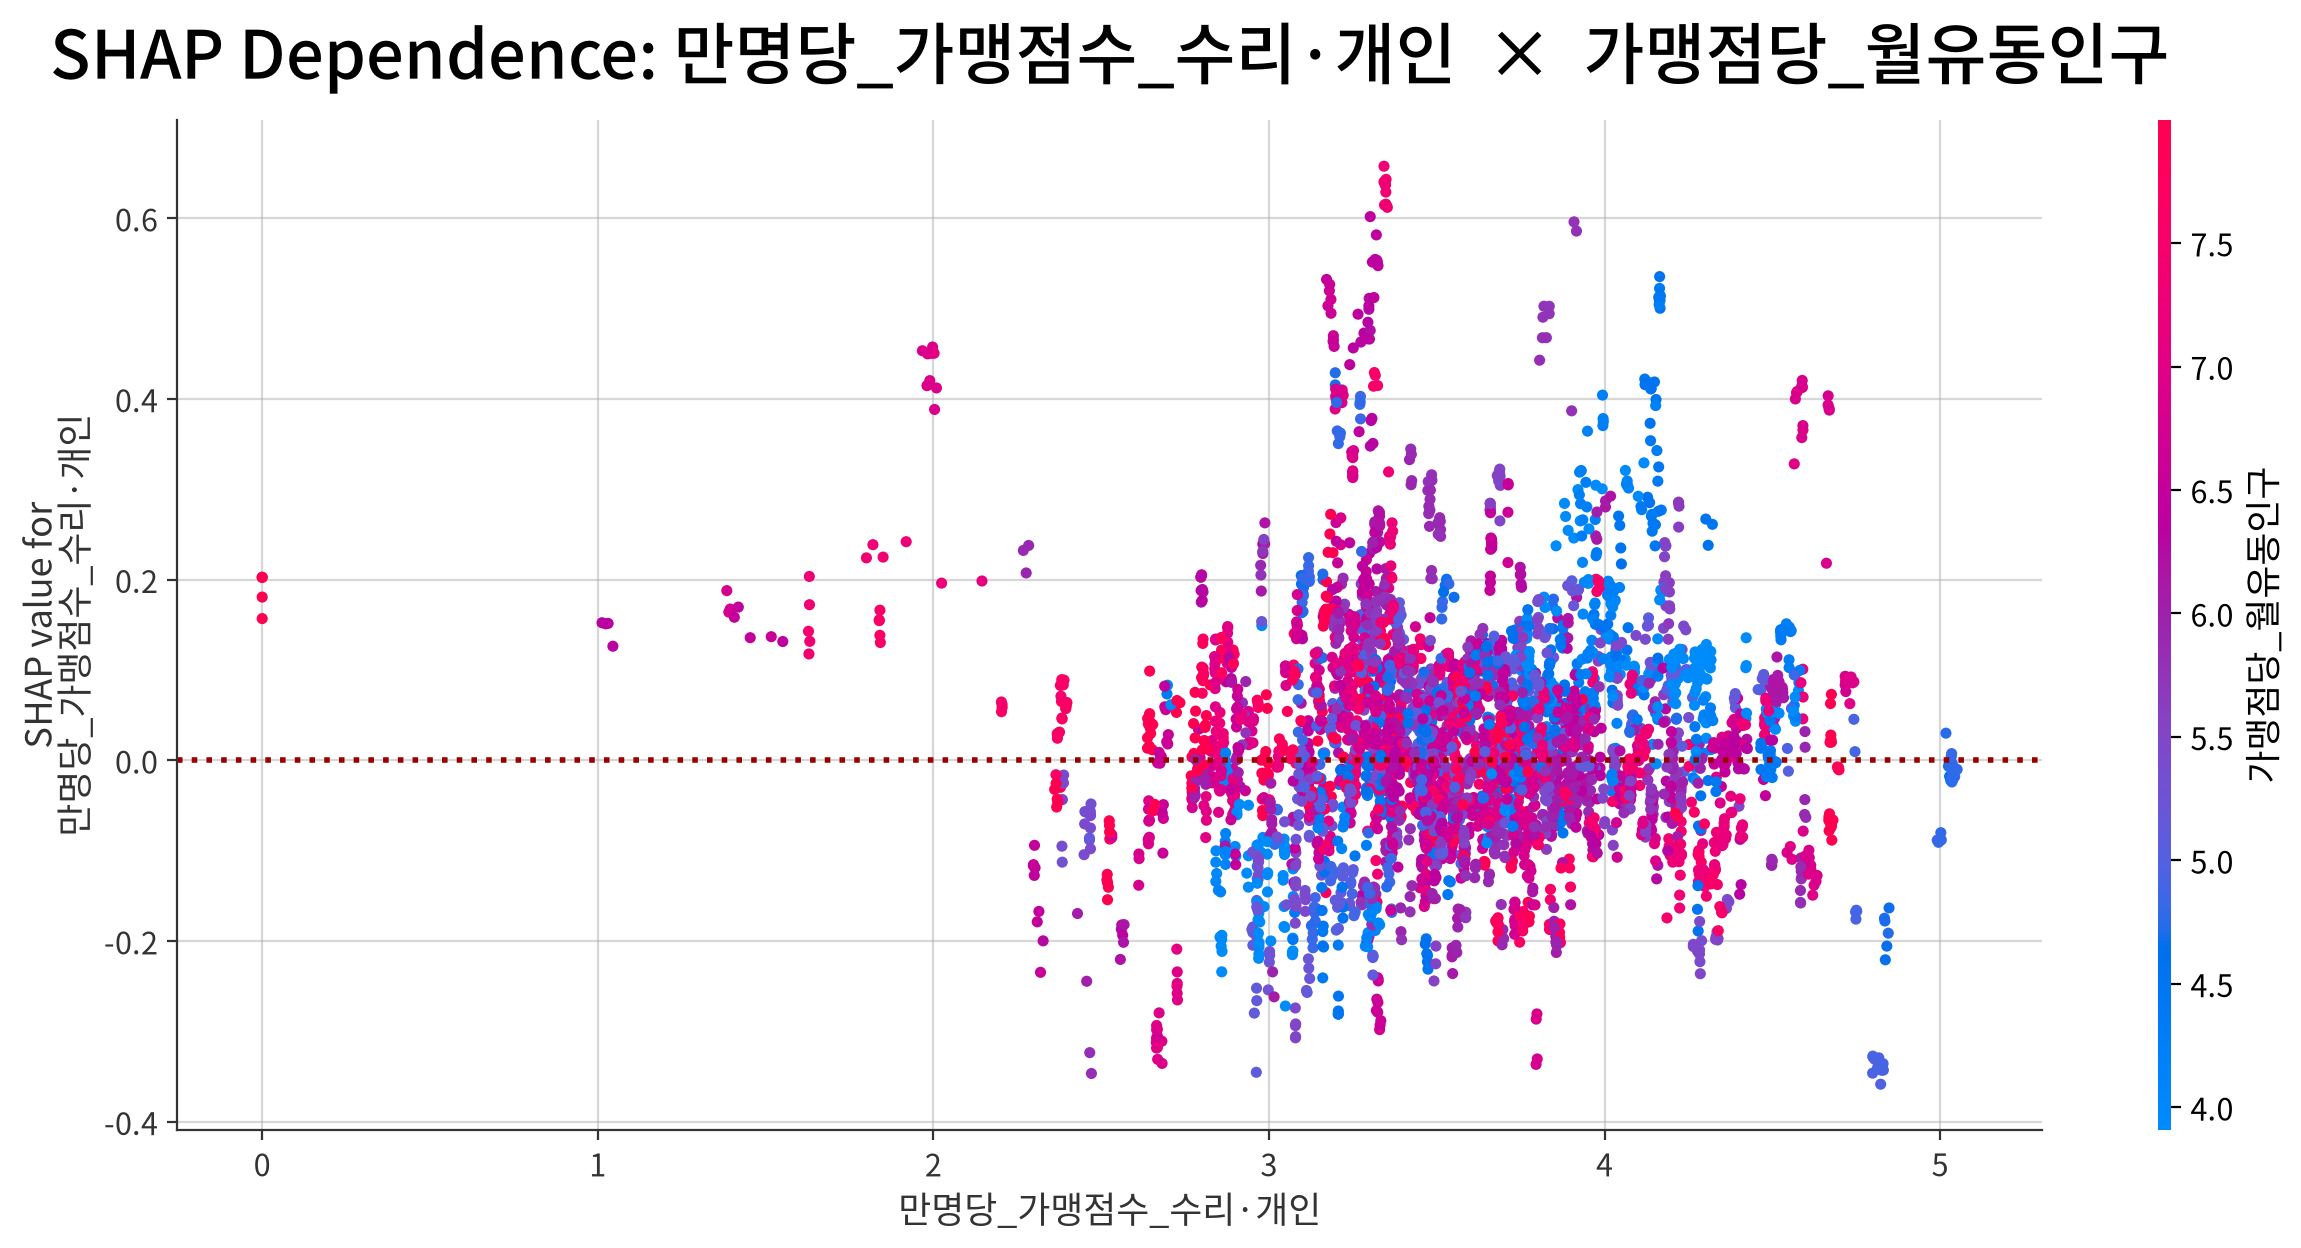

In [48]:
my_diag.shap_dependence_plot(summary, cum_ratio=cum_ratio, column_means=column_means)

### 시점별 예측 기여는 일정한 계절 패턴으로 단순화하기 어렵다

- 연도 코드 0은 양의 기여가 나타나고, 코드 1·2는 대체로 음의 기여를 보인다. 같은 연도 안에서도 기여 크기에 차이가 있다.
- 기준월 코드 6·7에서는 양의 기여가 두드러지며, 같은 월 코드에서도 연도에 따라 기여 크기가 다르게 나타난다.
- 앞선 라벨링 기준으로 코드 6·7은 7·8월이다. 다만 관측 기간의 연도별 월 구성이 다르므로, 이를 매년 반복되는 동일한 계절 효과로 확정하지 않는다.
- 시점 정보가 높은 순위에 있다는 결과는 정책 변화의 효과를 직접 보여주지 않는다. 현재 모델이 관측 기간의 매출 차이를 예측에 활용한 결과로 해석한다.

### 시점별 예측 기여는 일정한 계절 패턴으로 단순화하기 어렵다

- 연도 코드 0은 양의 기여가 나타나고, 코드 1·2는 대체로 음의 기여를 보인다. 같은 연도 안에서도 기여 크기에 차이가 있다.
- 기준월 코드 6·7에서는 양의 기여가 두드러지며, 같은 월 코드에서도 연도에 따라 기여 크기가 다르게 나타난다.
- 앞선 라벨링 기준으로 코드 6·7은 7·8월이다. 다만 관측 기간의 연도별 월 구성이 다르므로, 이를 매년 반복되는 동일한 계절 효과로 확정하지 않는다.
- 시점 정보가 높은 순위에 있다는 결과는 정책 변화의 효과를 직접 보여주지 않는다. 현재 모델이 관측 기간의 매출 차이를 예측에 활용한 결과로 해석한다.

### 가맹점당 유동 수준을 실제 이용 전환으로 해석하지 않는다

- 가맹점당 월유동인구는 높은 구간에서 음의 기여가 많이 나타나지만, 중간 구간에는 양·음의 기여가 함께 분포한다.
- 이 지표가 크다는 이유만으로 지역화폐 매출 예측이 높아지는 구조는 확인되지 않는다.
- 해당 변수는 지역 유동인구를 가맹점 수로 나눈 상대 지표다. 실제 방문객 수나 구매 전환율이 아니므로, 음의 기여를 이용 전환 실패나 가맹점 부족의 직접 증거로 해석하지 않는다.

In [50]:
base_value = summary.attrs['expected_value']    # 출발점 (평균 예측)
feat_names = summary.attrs['feature_names']     # 모델공간 변수명

# 가산성 - 행별 예측 = base value + 그 행의 SHAP 합
pred = base_value + shap_2d.sum(axis=1)
print(f'pred: {pred[:5]}')

print(f'base value: {base_value:.4f}')
print(f'복원한 예측의 최소값 {pred.min():.4f}')
print(f'복원한 예측의 중앙값 {np.median(pred):.4f}')
print(f'복원한 예측의 최대값 {pred.max():.4f}')

pred: [ 9.36647986 18.50114124 12.70215206 12.47856738 12.16691962]
base value: 13.9041
복원한 예측의 최소값 8.7074
복원한 예측의 중앙값 13.5968
복원한 예측의 최대값 20.3623


In [51]:
med = np.median(pred)                          # 예측값의 실제 중앙값
i = int(np.argmin(np.abs(pred - med)))         # 중앙값과 차이가 가장 작은 행 위치
quantile = (pred <= pred[i]).mean()            # 예측값 분포에서의 위치

print(f'중앙값과 가장 가까운 행: {i}행 / 예측값 {pred[i]:.4f} / 분포 위치 {quantile:.4%}')
print(f'중앙값 {med:.4f} / 고른 행의 예측 {pred[i]:.4f}')

# 고른 행이 어떤 값을 가진 사례인지 표로 확인한다
pick_df = x_df.iloc[[i]].copy()
pick_df.insert(0, 'pred', pred[i])             # 복원한 예측값
pick_df.insert(0, 'quantile', quantile)        # 예측값 분포에서의 위치

pick_df

중앙값과 가장 가까운 행: 4301행 / 예측값 13.5968 / 분포 위치 50.0200%
중앙값 13.5968 / 고른 행의 예측 13.5968


,quantile,pred,총인구수,만명당_가맹점수_보건의료,만명당_가맹점수_예술·스포츠,만명당_가맹점수_시설관리·임대,가맹점당_월유동인구,만명당_가맹점수_과학·기술,만명당_가맹점수_소매,만명당_가맹점수_음식,만명당_가맹점수_기타,만명당_가맹점수_수리·개인,만명당_가맹점수_부동산,기준월,년도
671,0.500,13.597,10.714,2.885,3.219,1.099,7.281,1.881,4.656,5.189,2.663,4.282,0.201,5,2


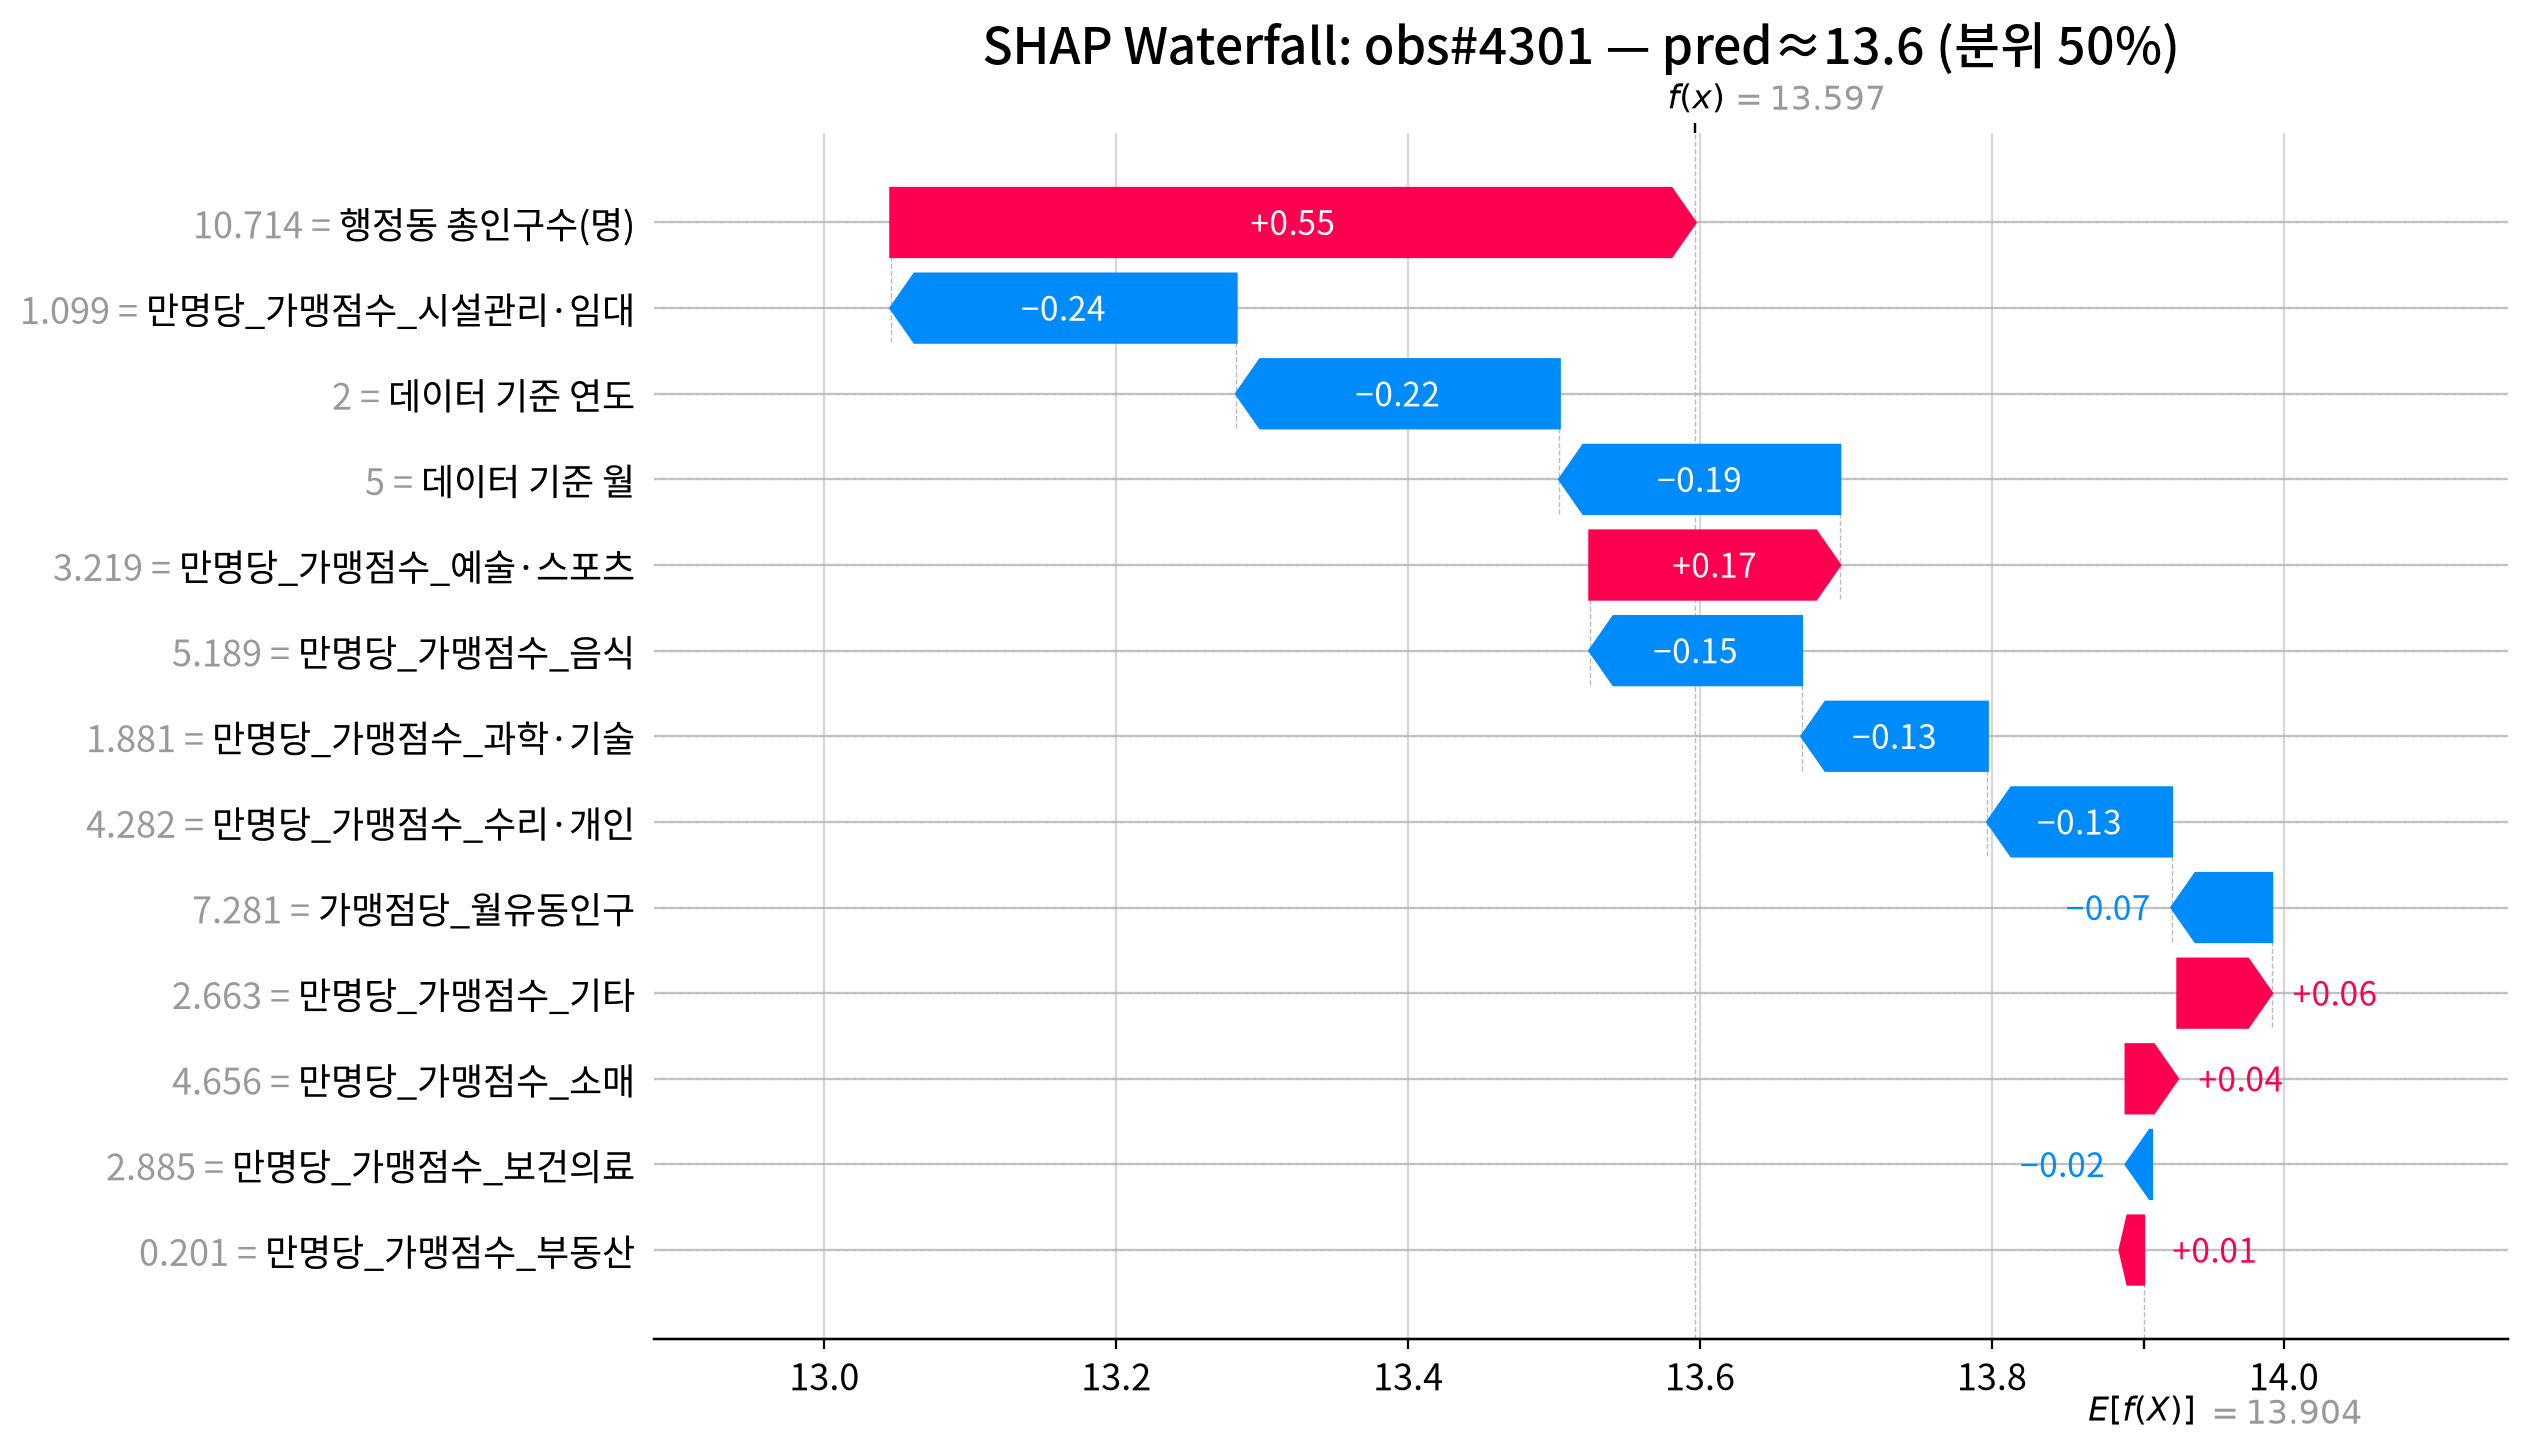

,quantile,pred,총인구수,만명당_가맹점수_보건의료,만명당_가맹점수_예술·스포츠,만명당_가맹점수_시설관리·임대,가맹점당_월유동인구,만명당_가맹점수_과학·기술,만명당_가맹점수_소매,만명당_가맹점수_음식,만명당_가맹점수_기타,만명당_가맹점수_수리·개인,만명당_가맹점수_부동산,기준월,년도
671,0.500,13.597,10.714,2.885,3.219,1.099,7.281,1.881,4.656,5.189,2.663,4.282,0.201,5,2


In [52]:
my_diag.shap_waterfall_plot(summary,
                            index=i,
                            cum_ratio=cum_ratio,
                            column_means=column_means)

### 중간 수준의 예측도 서로 다른 방향의 기여가 합쳐진 결과다

- 선택한 사례의 로그 매출 예측은 약 13.5968로, SHAP 기준값 13.9041보다 낮다.
- 총인구수는 약 +0.55로 예측을 높였지만, 시설관리·임대와 연도·월 등은 예측을 낮추는 방향으로 기여했다.
- 중간 수준의 예측값이 모든 변수의 작은 기여로 만들어진 것은 아니다. 상대적으로 큰 양의 기여와 여러 음의 기여가 상쇄된 결과다.
- 이 사례는 예측값 분포의 중앙값에 가까운 관측치이며, 실제 매출의 중앙값에 해당하는 지역으로 선정한 것은 아니다.

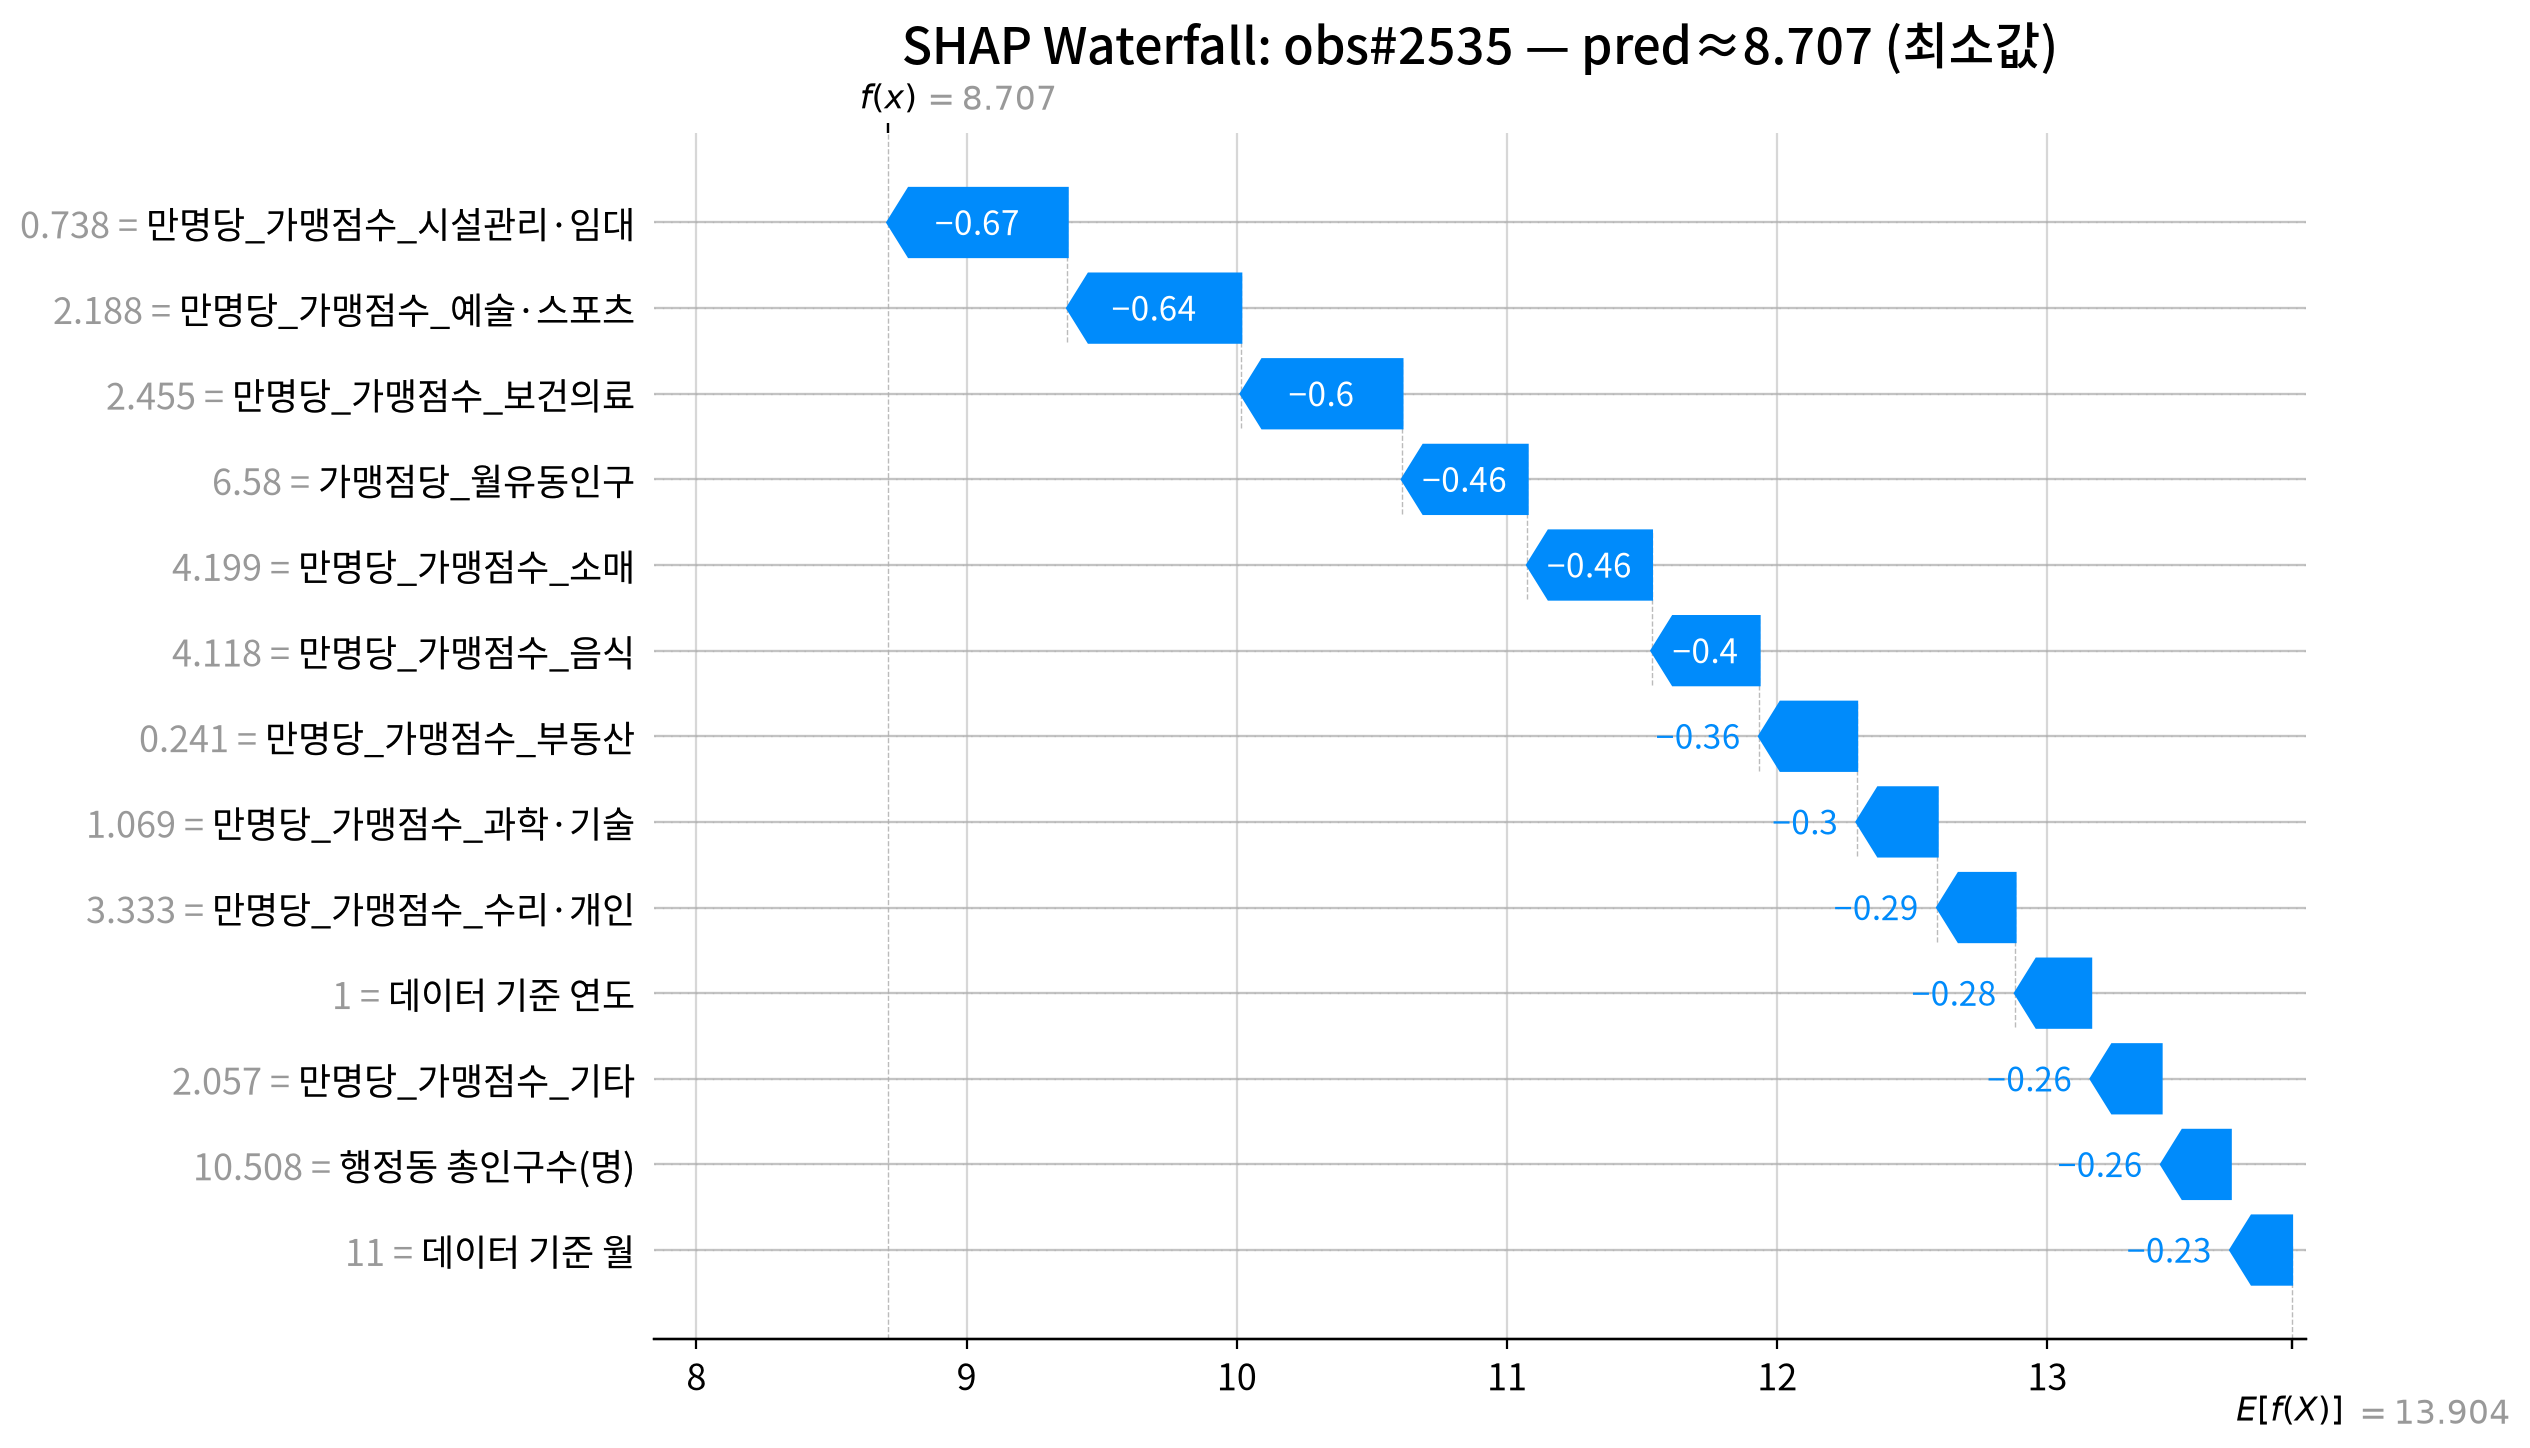

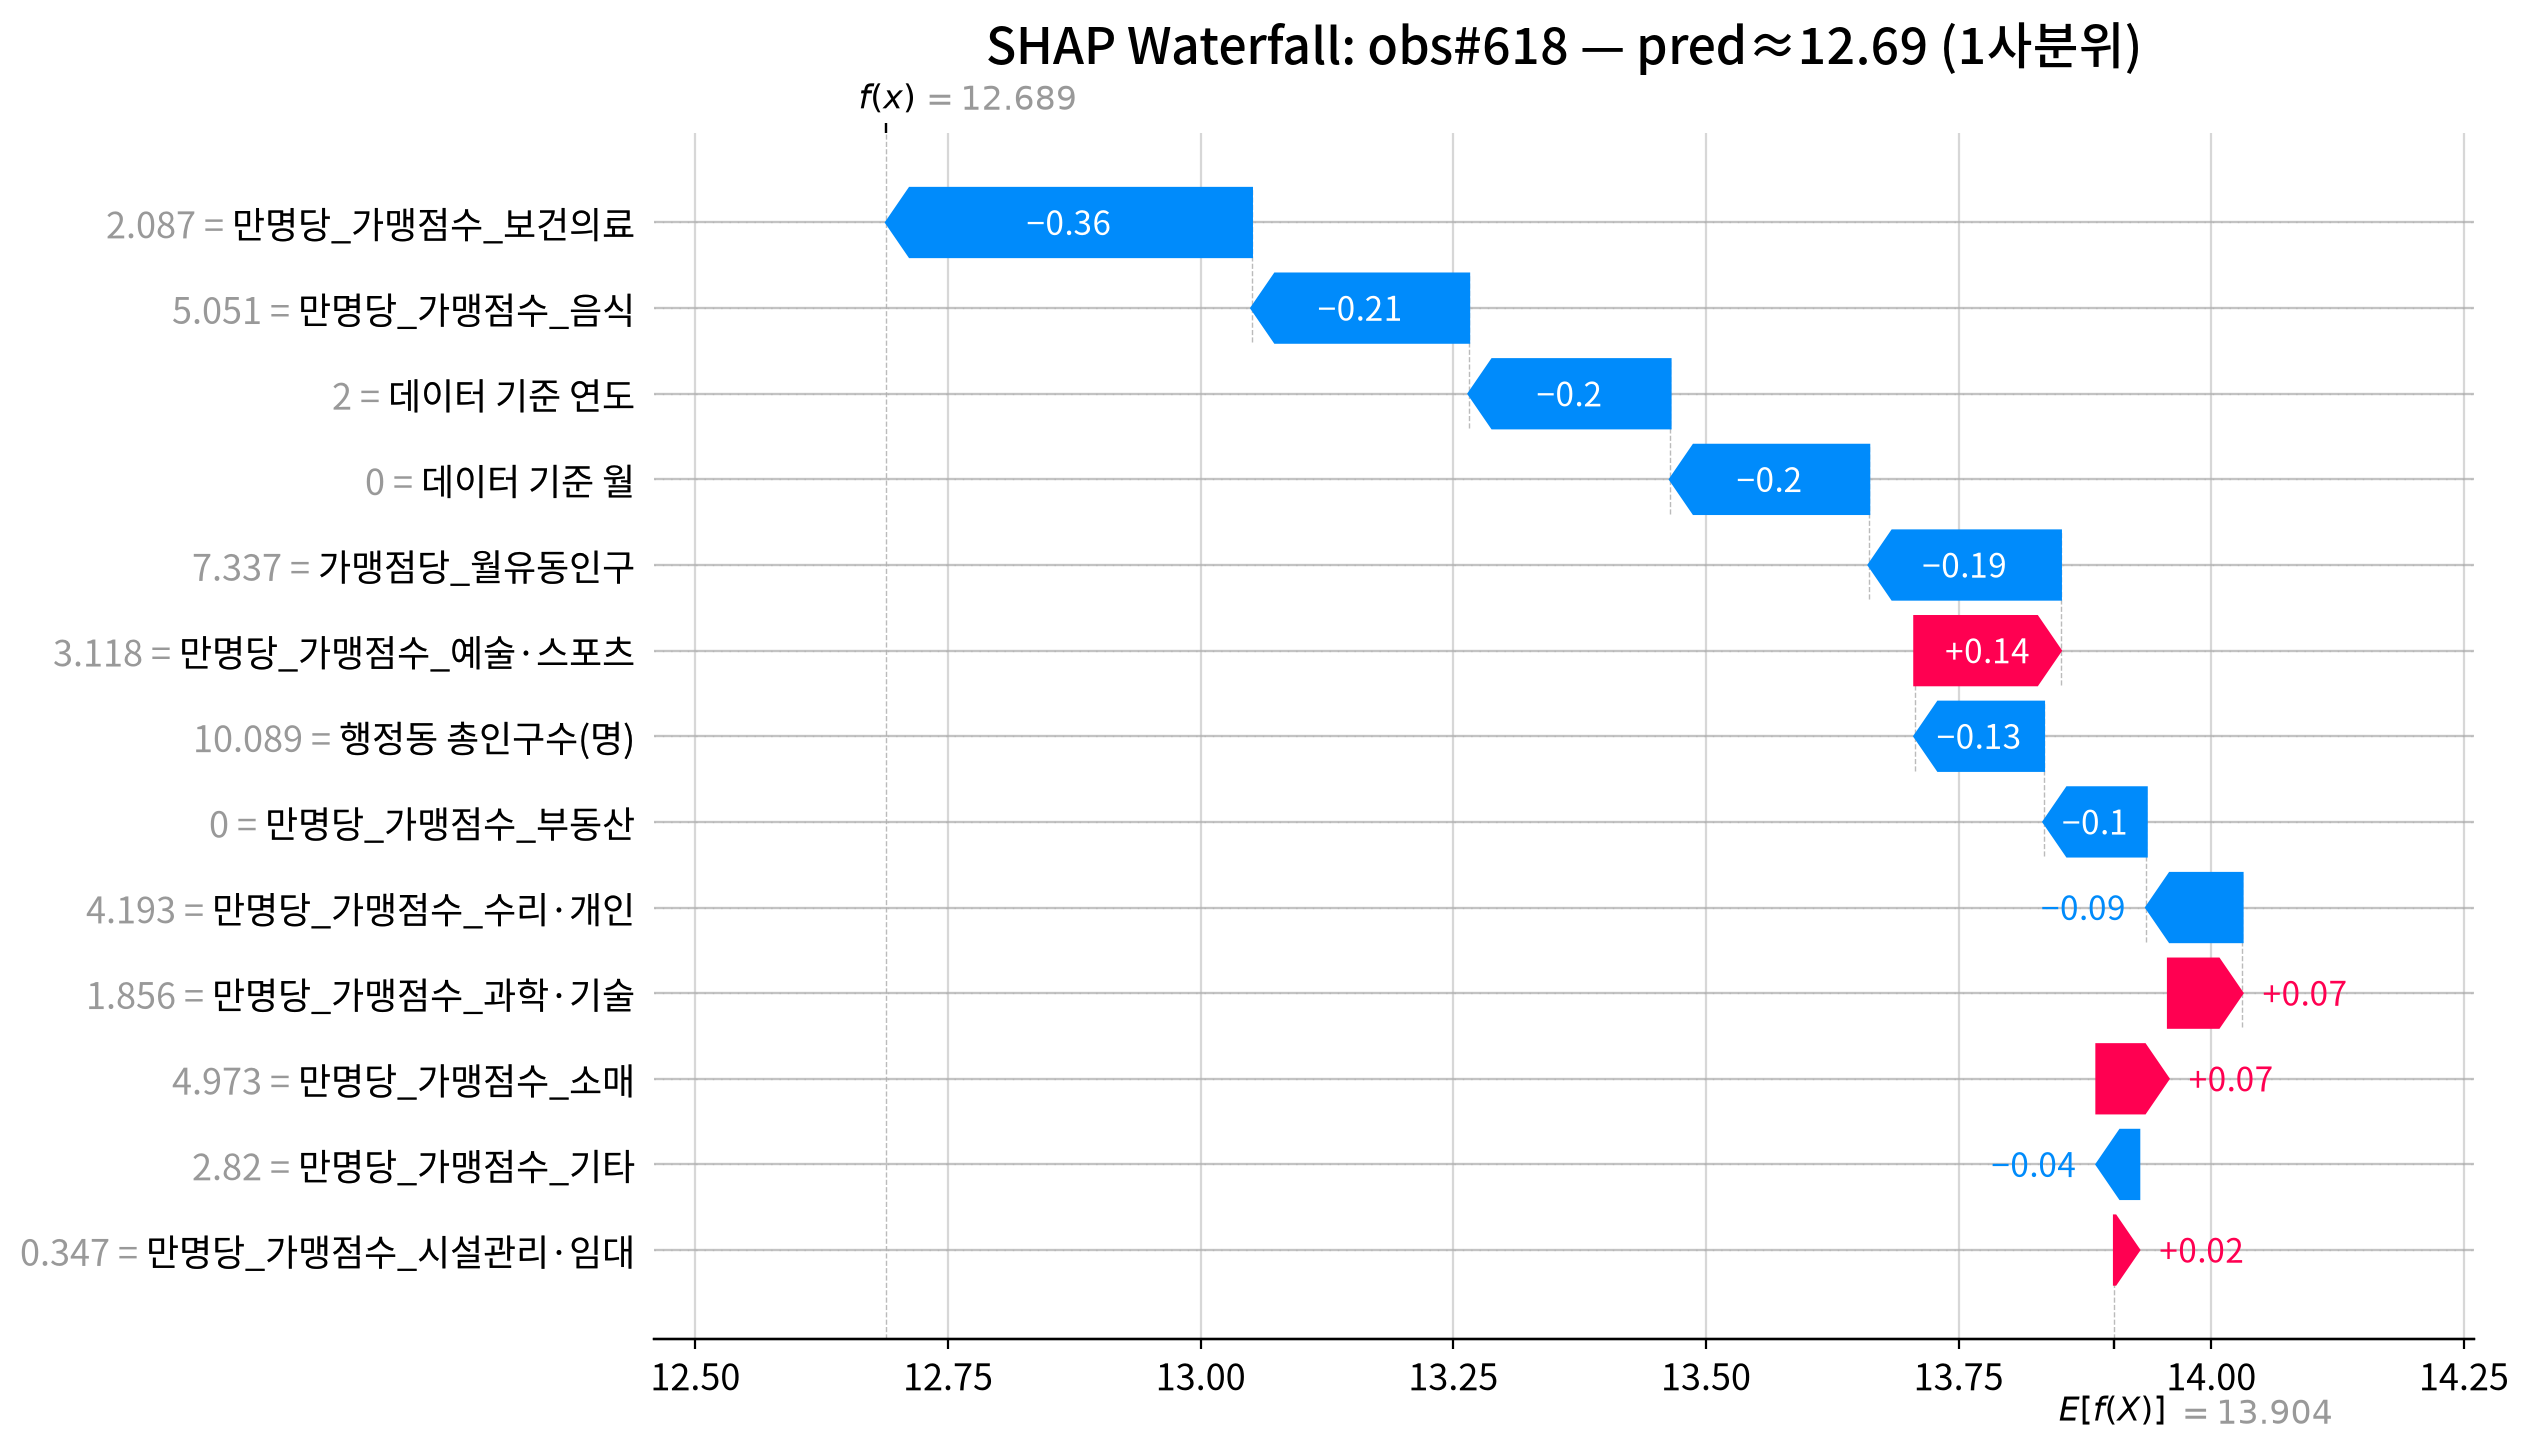

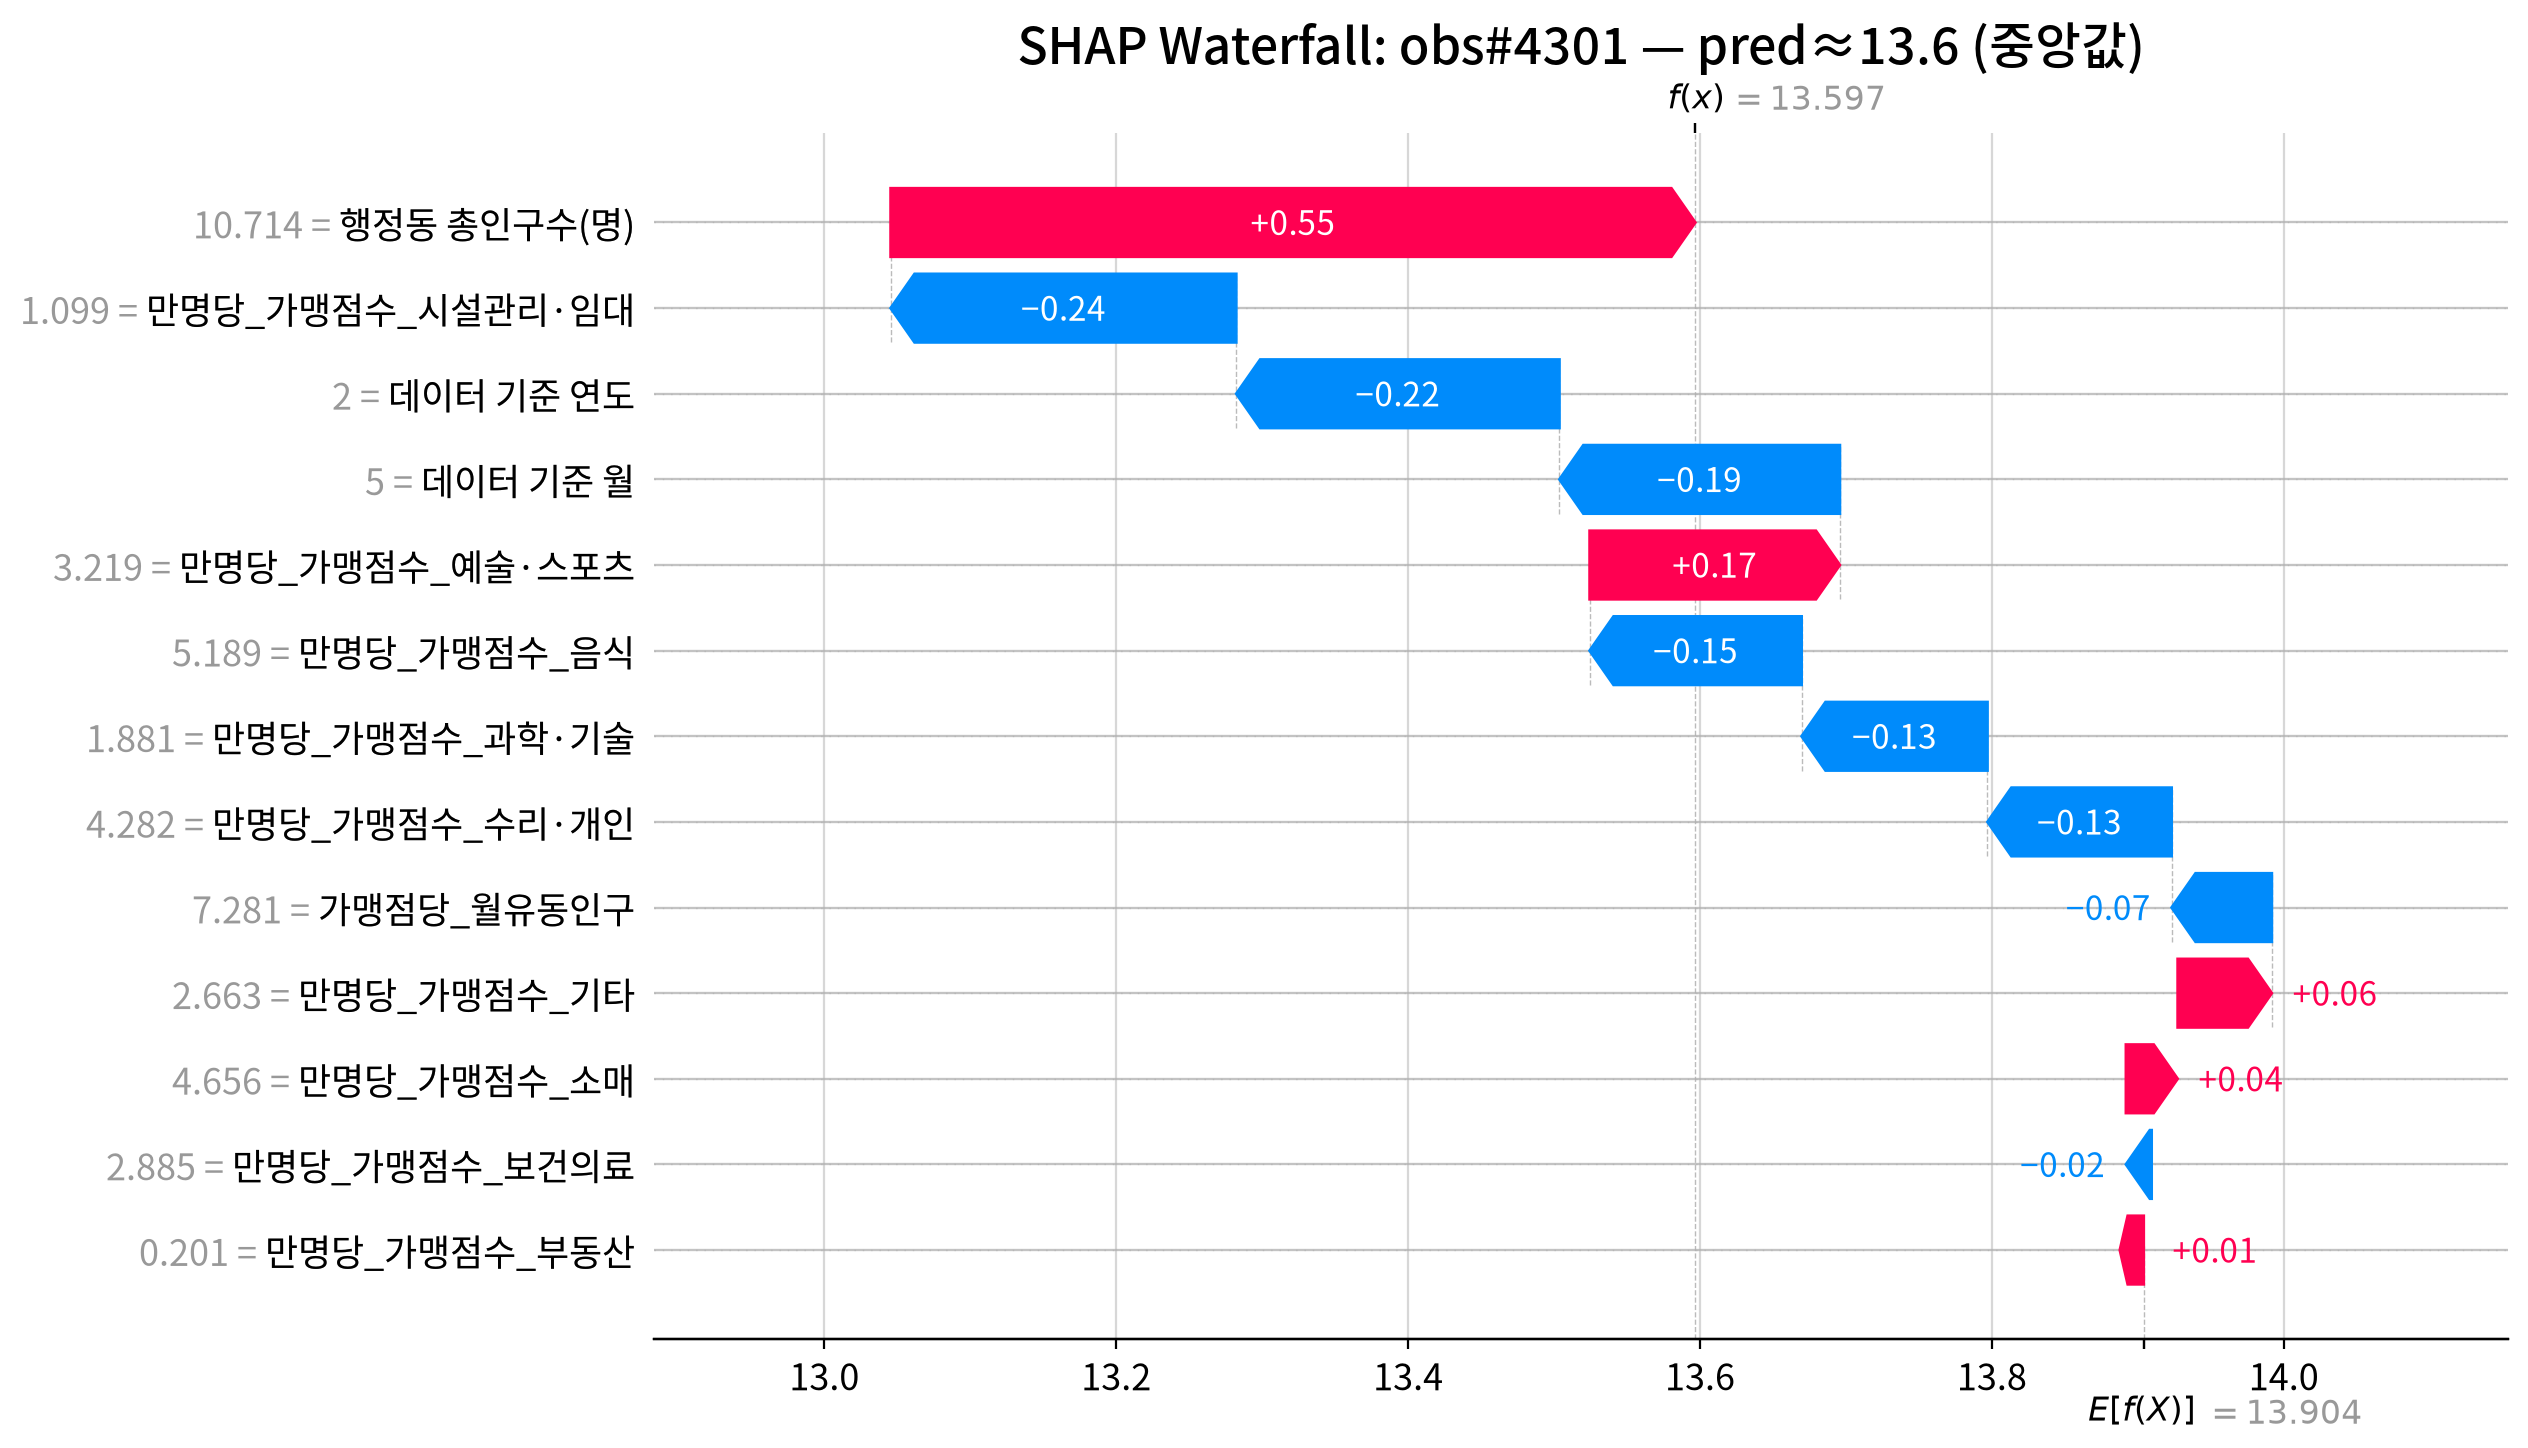

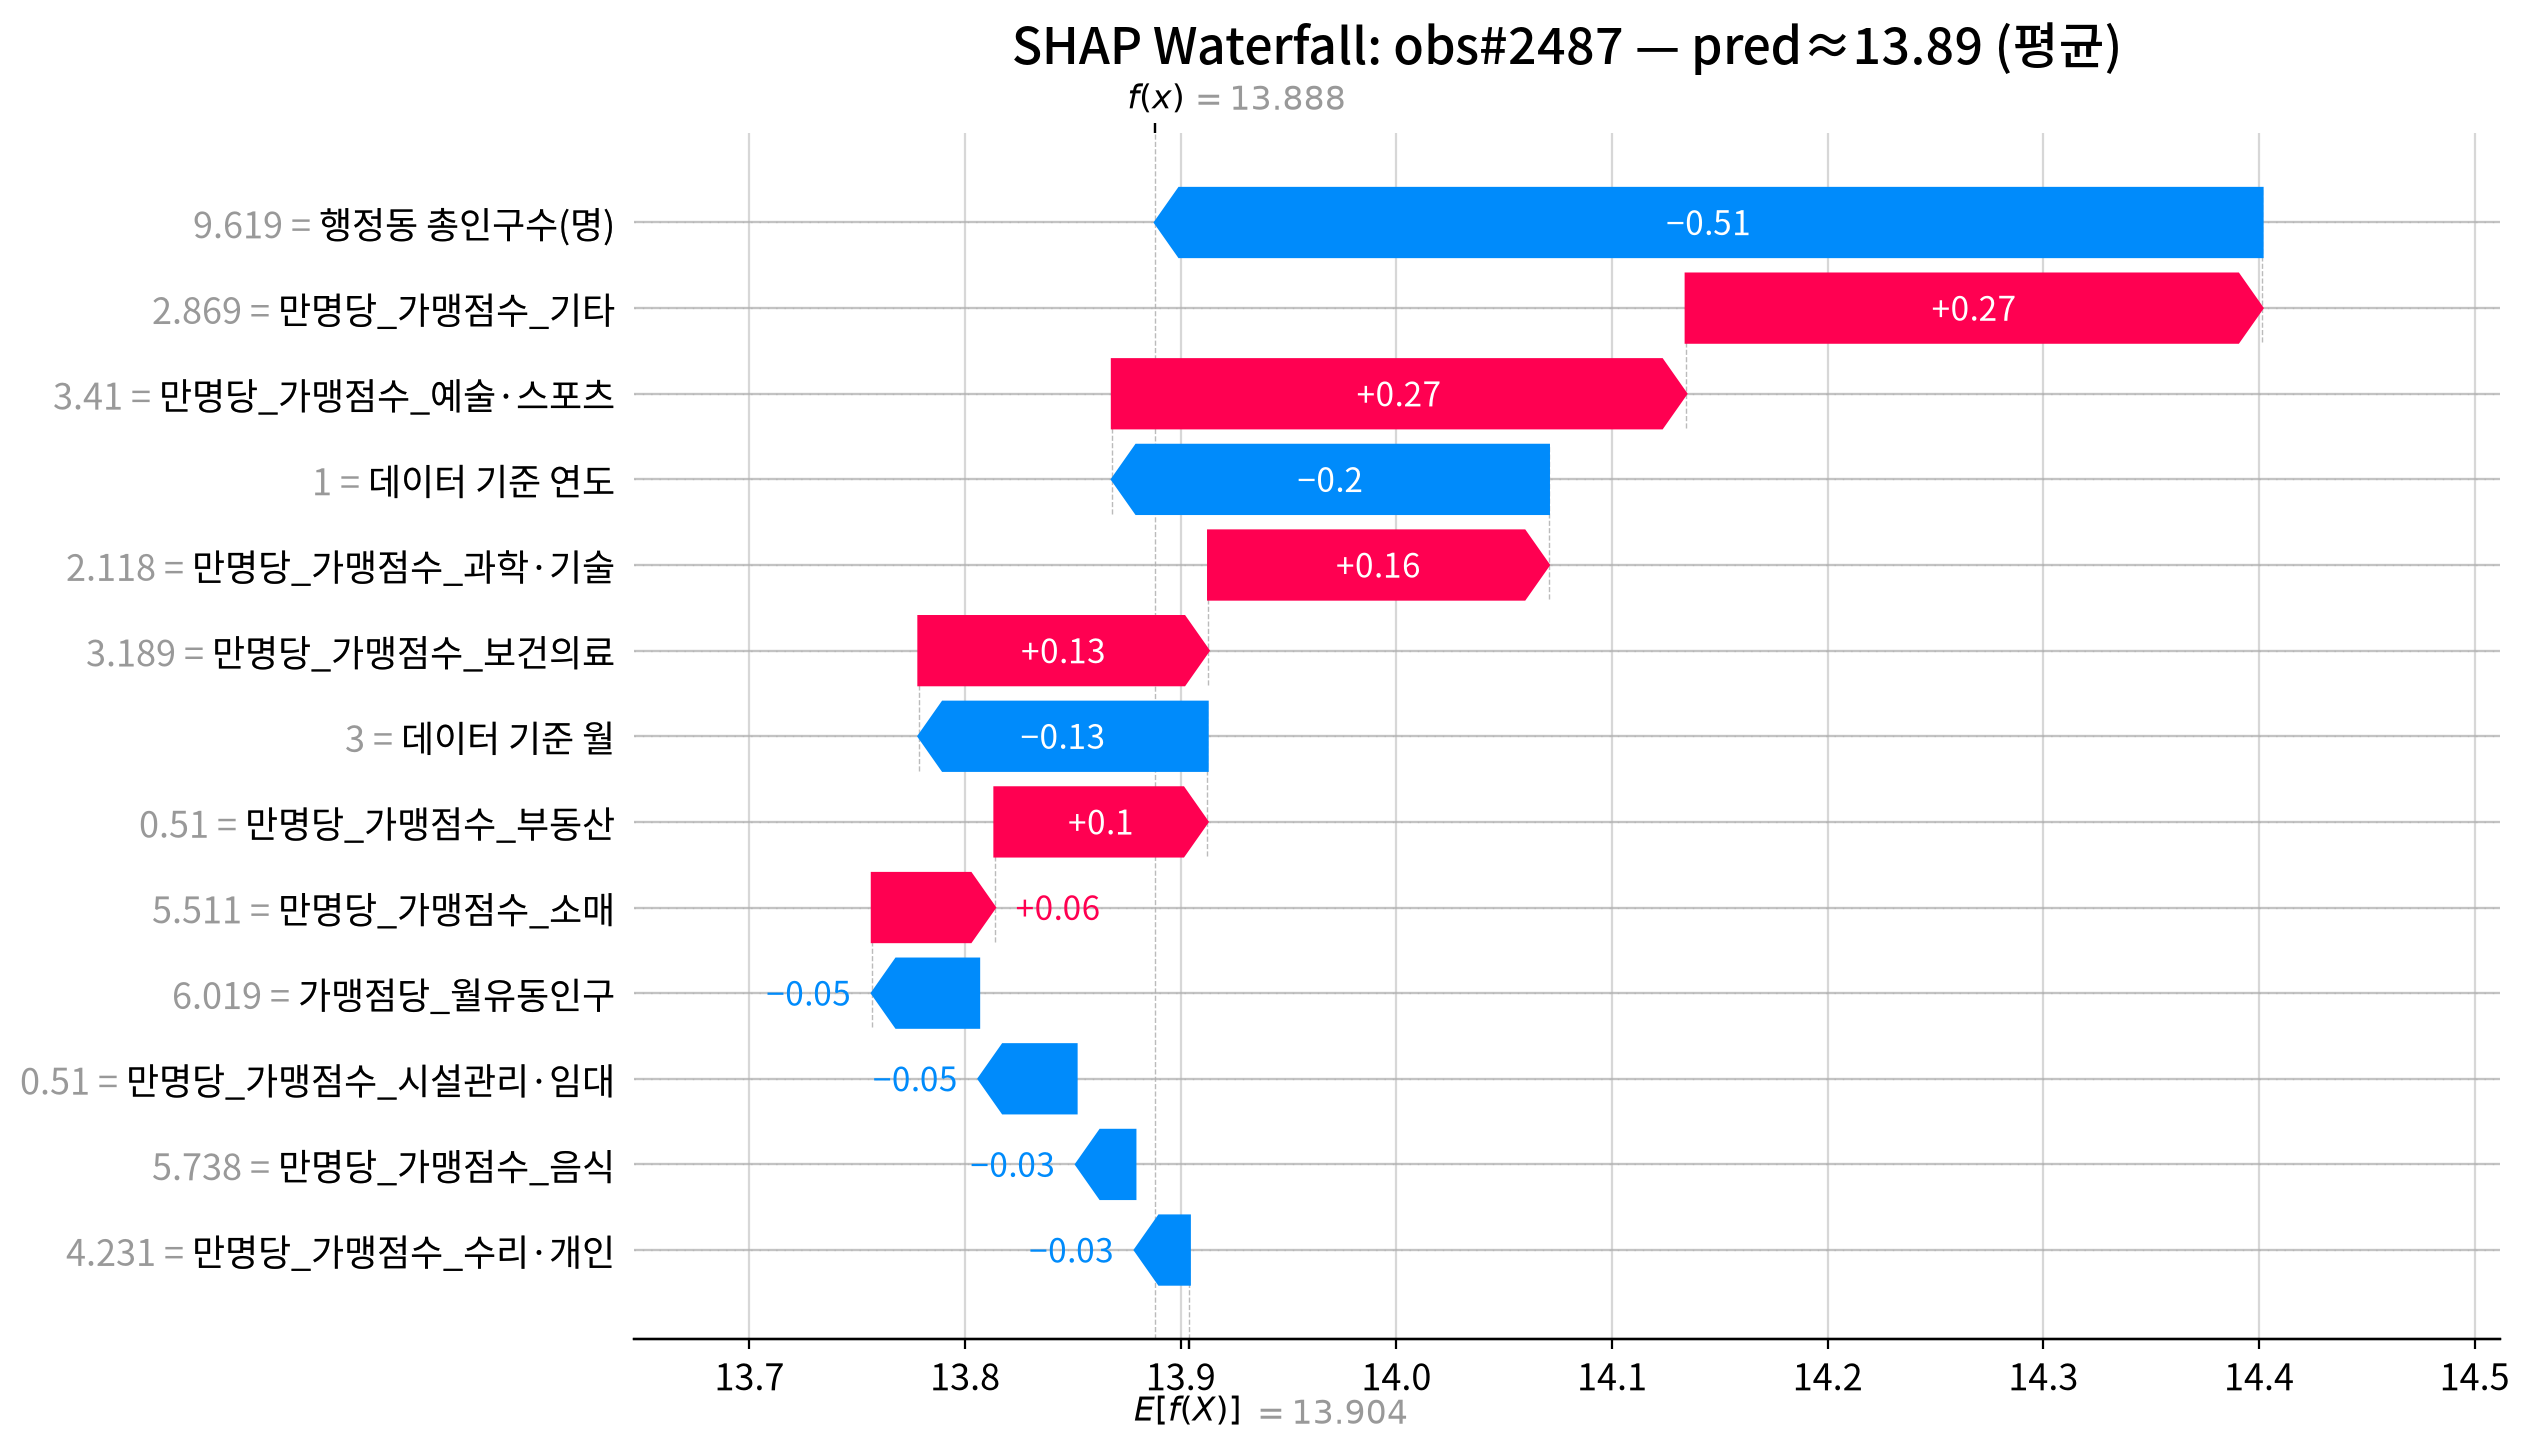

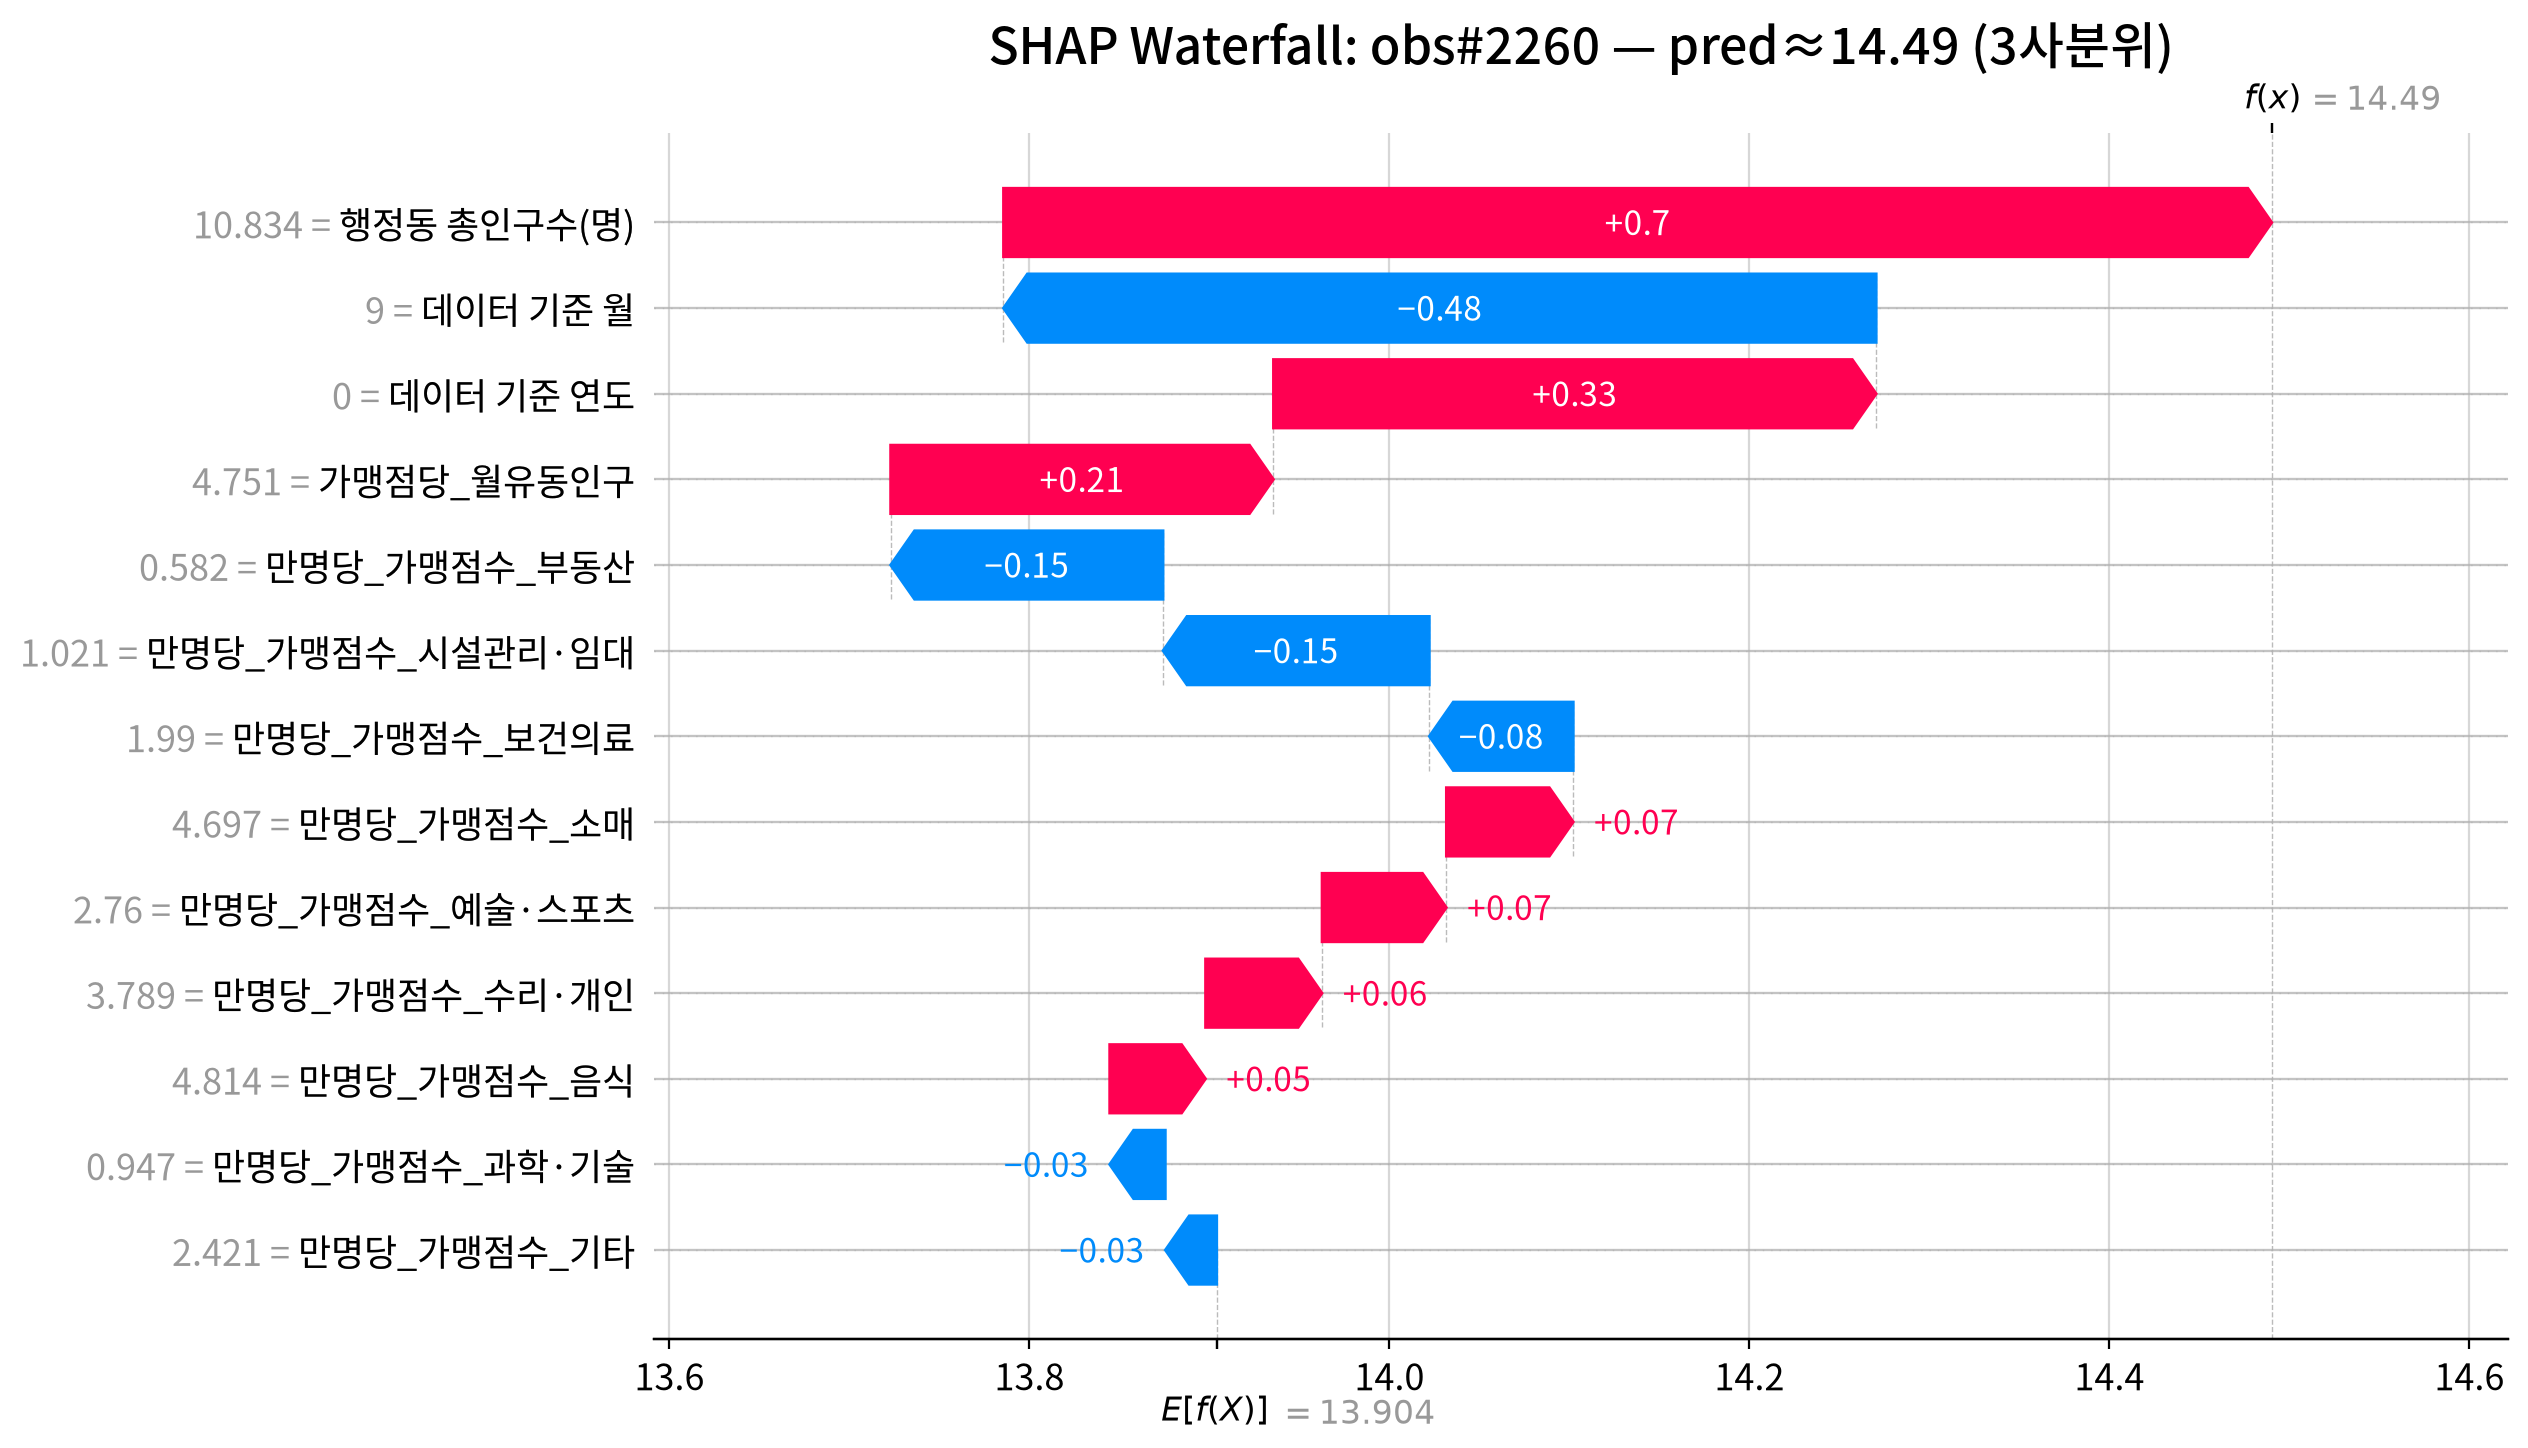

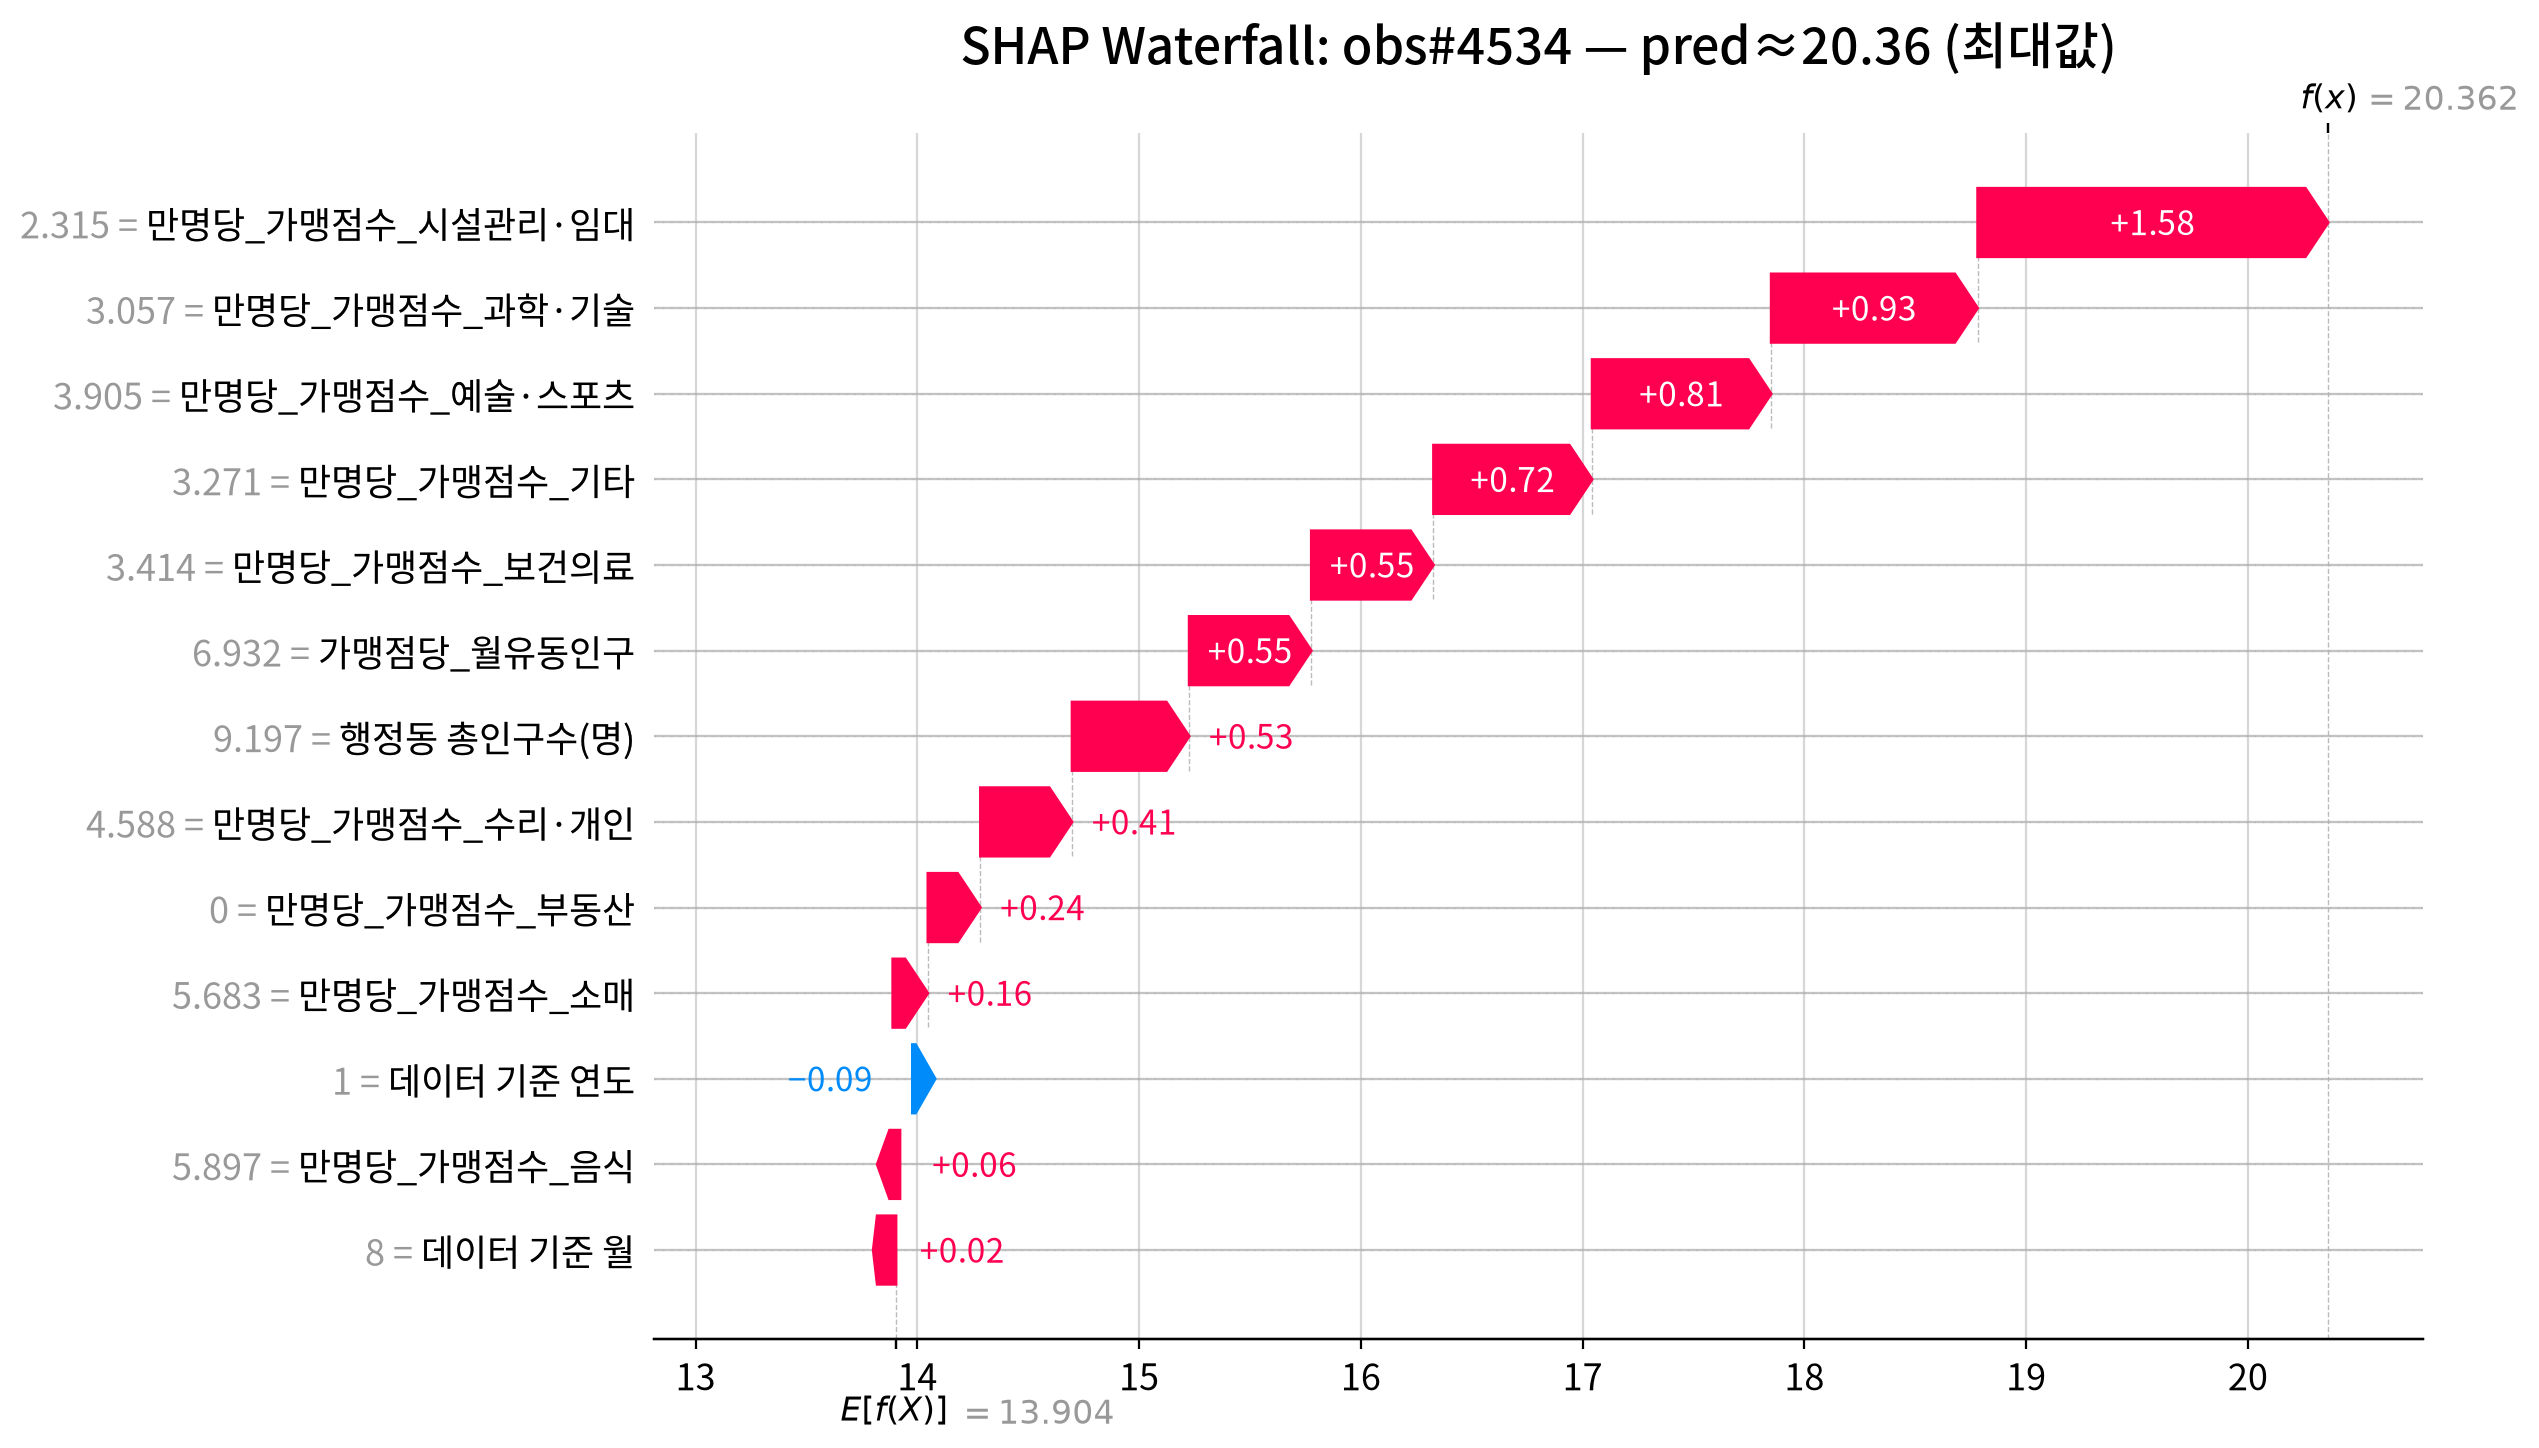

,stat,quantile,pred,총인구수,만명당_가맹점수_보건의료,만명당_가맹점수_예술·스포츠,만명당_가맹점수_시설관리·임대,가맹점당_월유동인구,만명당_가맹점수_과학·기술,만명당_가맹점수_소매,만명당_가맹점수_음식,만명당_가맹점수_기타,만명당_가맹점수_수리·개인,만명당_가맹점수_부동산,기준월,년도
4745,최소값,0.000,8.707,10.508,2.455,2.188,0.738,6.580,1.069,4.199,4.118,2.057,3.333,0.241,11,1
402,1사분위,0.250,12.689,10.089,2.087,3.118,0.347,7.337,1.856,4.973,5.051,2.820,4.193,0.000,0,2
671,중앙값,0.500,13.597,10.714,2.885,3.219,1.099,7.281,1.881,4.656,5.189,2.663,4.282,0.201,5,2
3897,평균,0.590,13.888,9.619,3.189,3.410,0.510,6.019,2.118,5.511,5.738,2.869,4.231,0.510,3,1
6027,3사분위,0.750,14.490,10.834,1.990,2.760,1.021,4.751,0.947,4.697,4.814,2.421,3.789,0.582,9,0
494,최대값,1.000,20.362,9.197,3.414,3.905,2.315,6.932,3.057,5.683,5.897,3.271,4.588,0.000,8,1


In [53]:
my_diag.shap_waterfall_stats_plot(summary,
                                  cum_ratio=cum_ratio,
                                  column_means=column_means)

### 낮은 예측과 높은 예측을 만드는 변수 조합은 다르다

- 최소 예측 사례에서는 표시된 모든 변수의 기여가 음수다. 시설관리·임대·예술·스포츠·보건의료를 비롯한 여러 음의 기여가 누적되어 기준값보다 낮은 예측을 만들었다.
- 최대 예측 사례에서는 시설관리·임대가 약 +1.58로 가장 큰 양의 기여를 보였고, 과학·기술과 예술·스포츠 등도 예측을 높였다. 전체 중요도 1위인 연도가 이 사례에서도 가장 큰 기여를 한 것은 아니다.
- 3사분위 사례에서는 인구의 양의 기여와 월의 음의 기여가 함께 나타난다. 높은 예측값이라고 모든 변수가 같은 방향으로 기여하는 것은 아니다.
- 이 비교는 예측 분포에서 선택한 개별 사례의 설명이다. 실제 최저·최고 매출 지역이나 특정 군집 전체의 특성으로 일반화하지 않는다.

### 지역 유형 분석과 예측 해석을 나누어 활용

- 앞선 군집분석은 유사한 인구·가맹점 특성을 가진 지역을 구분하는 근거이고, SHAP은 분석된 모델이 개별 예측을 어떻게 구성했는지 설명하는 결과다.
- 현재 SHAP에는 군집 변수가 없으므로, 특정 군집이 예측 매출을 높이거나 낮춘다는 결론은 제시하지 않는다.
- 업종별 지표의 기여 방향이 구간과 사례에 따라 달라져, 특정 업종의 가맹점을 늘리는 처방으로 바로 연결하기 어렵다.
- 지역 유형별 검토 대상을 정한 뒤 개별 지역의 사용처·이용자·시점 정보를 추가 확인하는 데 활용할 수 있으며, 정책 효과나 지원 우선순위를 확정하는 근거로 사용하지 않는다.